In [ ]:
# =========================================================
# 0. Imports
# =========================================================
from __future__ import annotations

import os
import json
import copy
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst  # noqa: E402

In [2]:
# =========================================================
# 1. Paths and basic config
# =========================================================
OUT_ROOT = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/Results_HW_PNW21/")
SUMMARY_CSV = OUT_ROOT / "hyperparam_search_summary.csv"
SUMMARY_PKL = OUT_ROOT / "hyperparam_search_summary.pkl"

# optional: event info for plotting
event_lat = 52.5
event_lon = 240.0

# optional: set this if you want to reload the original data for plotting densities
PATH_FILES = "/glade/derecho/scratch/jhayron/DataCaStLeBTs/JointFiles/"
TIME_SLICE = ("2021-05-20", "2021-06-30")

VAR_NAME_MAP = {
    "z500": "Z500",
    "olr": "MTNLWRF",
    "skt": "SKT",
    "slhf": "MSLHF",
    "sshf": "MSSHF",
    "tclw": "TCLW",
    "tcwv": "TCWV",
    "vimd": "MVIMD",
    "w500": "W500",
    "z100": "Z100",
    "z10": "Z10",
}

VAR_COMBO = ["z500", "z10", "olr", "vimd", "tcwv", "slhf", "sshf"]
date_end = "2021-06-30"

In [3]:
def load_full_data_for_vars(varstems: List[str]) -> xr.DataArray:
    list_names = [VAR_NAME_MAP[v] for v in varstems]
    full_data = tst.data_io.load_full_data(
        path_files=PATH_FILES,
        varstems=varstems,
        list_names_vars=list_names,
        time_slice=TIME_SLICE,
        join="inner",
    )
    return full_data

In [4]:
full_data_run = load_full_data_for_vars(VAR_COMBO)

In [5]:
# define target 2.5° grid
new_lats = np.arange(-30, 90.0 + 2.5, 2.5)
new_lons = np.arange(0, 360, 2.5)

full_data_run_2p5 = full_data_run.interp(
    lat=new_lats,
    lon=new_lons,
    method="linear"
)

print(full_data_run_2p5)

full_data_run = full_data_run_2p5

<xarray.DataArray 'z500' (var: 7, lat: 49, lon: 144, time: 42)> Size: 17MB
array([[[[-1.02841532, -0.00930475,  0.24308337, ..., -2.48365927,
          -1.63520002,  0.25249168],
         [-1.22718322, -0.18940932,  0.32770862, ..., -2.45128524,
          -1.93025327, -0.022622  ],
         [-1.39487946, -0.38274649,  0.35252264, ..., -2.30190587,
          -2.2007463 , -0.29980236],
         ...,
         [-0.35484366,  0.22470157, -0.36685538, ..., -1.66578263,
          -0.47627376,  0.92368698],
         [-0.58200592,  0.21778741, -0.12301873, ..., -2.10458732,
          -0.87967473,  0.75397456],
         [-0.80948234,  0.14760059,  0.0892944 , ..., -2.37346721,
          -1.28020626,  0.52777605]],

        [[-0.96217132, -0.14013359,  0.25782384, ..., -2.9848671 ,
          -1.65576196,  0.6082384 ],
         [-1.03806537, -0.28063367,  0.26809442, ..., -2.88445199,
          -2.11572498,  0.30429885],
         [-1.09197736, -0.41250648,  0.25116808, ..., -2.56116915,
          

In [6]:
# =========================================================
# 2. Load summary table
# =========================================================
if SUMMARY_PKL.exists():
    df = pd.read_pickle(SUMMARY_PKL)
else:
    df = pd.read_csv(SUMMARY_CSV)

print(df.shape)
display(df.head())

(500, 143)


,run_id,n_requested,n_success,n_failed,success_rate,mean_steps,median_steps,min_steps,max_steps,fraction_full_length,...,days_21_30_parent_freq_norm_TCWV,days_21_30_parent_freq_norm_MSLHF,days_21_30_parent_freq_norm_MSSHF,days_21_30_top5frac_Z500,days_21_30_top5frac_Z10,days_21_30_top5frac_MTNLWRF,days_21_30_top5frac_MVIMD,days_21_30_top5frac_TCWV,days_21_30_top5frac_MSLHF,days_21_30_top5frac_MSSHF
0,0,100,0,100,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100,100,0,1.0,27.66,31.0,5.0,31.0,0.01,...,0.129397,0.224874,0.150754,0.617076,0.672973,0.503392,0.524500,0.507287,0.522369,0.542950
2,2,100,0,100,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100,100,0,1.0,18.82,18.5,3.0,31.0,0.02,...,0.049315,0.123288,0.172603,0.714015,NaN,0.367370,0.278582,0.546695,0.263591,0.249051
4,4,100,0,100,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# =========================================================
# 3. Quick overview
# =========================================================
basic_cols = [
    "run_id",
    "n_requested",
    "n_success",
    "n_failed",
    "success_rate",
    "mean_steps",
    "fraction_full_length",
    "mean_displacement_km",
    "mean_path_length_km",
    "mean_unique_parents",
    "parent_entropy_all",
    "step_10_mean_radius_km",
    "step_20_mean_radius_km",
    "step_30_mean_radius_km",
]

display(df[basic_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
run_id,500.0,249.500000,144.481833,0.000000,124.750000,249.500000,374.250000,499.000000
n_requested,500.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000
n_success,500.0,66.308000,46.261966,0.000000,0.000000,100.000000,100.000000,100.000000
n_failed,500.0,33.692000,46.261966,0.000000,0.000000,0.000000,100.000000,100.000000
success_rate,500.0,0.663080,0.462620,0.000000,0.000000,1.000000,1.000000,1.000000
mean_steps,372.0,23.187585,5.651533,3.666667,20.827500,24.455000,27.290000,31.000000
fraction_full_length,372.0,0.007668,0.009962,0.000000,0.000000,0.000000,0.010000,0.062500
mean_displacement_km,372.0,3689.496813,791.985054,2269.715564,3036.170196,3576.247157,4168.168505,9202.555908
mean_path_length_km,372.0,16760.278600,4461.087083,2831.647599,14903.193198,16879.752966,19910.478864,28971.538017
mean_unique_parents,372.0,5.579558,0.770464,2.000000,5.350000,5.705000,6.122500,6.750000


In [55]:
df_filt.keys()[:20]

Index(['run_id', 'n_requested', 'n_success', 'n_failed', 'success_rate',
       'mean_steps', 'median_steps', 'min_steps', 'max_steps',
       'fraction_full_length', 'mean_displacement_km',
       'median_displacement_km', 'max_displacement_km', 'mean_path_length_km',
       'median_path_length_km', 'max_path_length_km', 'mean_step_length_km',
       'median_step_length_km', 'mean_net_displacement_km',
       'median_net_displacement_km'],
      dtype='object')

In [56]:
df_filt.keys()[20:40]

Index(['mean_unique_parents', 'median_unique_parents', 'parent_entropy_all',
       'step_10_n_members', 'step_10_mean_lat', 'step_10_mean_lon',
       'step_10_mean_radius_km', 'step_20_n_members', 'step_20_mean_lat',
       'step_20_mean_lon', 'step_20_mean_radius_km', 'step_30_n_members',
       'step_30_mean_lat', 'step_30_mean_lon', 'step_30_mean_radius_km',
       'days_1_10_total_integrated_density', 'days_1_10_integrated_Z500',
       'days_1_10_integrated_Z10', 'days_1_10_integrated_MTNLWRF',
       'days_1_10_integrated_MVIMD'],
      dtype='object')

In [72]:
# =========================================================
# 4. Filter obviously poor / unusable runs
# =========================================================
df_filt = df.copy()

# Convert key columns safely
for col in [
    "success_rate",
    "mean_steps",
    "median_steps",
    "fraction_full_length",
    "mean_displacement_km",
    "mean_path_length_km",
    "step_10_mean_radius_km",
    "step_20_mean_radius_km",
    "step_30_mean_radius_km",
    "mean_unique_parents",
    "parent_entropy_all",
]:
    if col in df_filt.columns:
        df_filt[col] = pd.to_numeric(df_filt[col], errors="coerce")

print("Total runs:", len(df_filt))

# Set your initial filters here
MIN_SUCCESS_RATE = 0.66
MIN_MEAN_STEPS = 25
MIN_MEAN_PATH_LENGTH = 0

mask_keep = (
    (df_filt["success_rate"] >= MIN_SUCCESS_RATE) &
    (df_filt["median_steps"] >= MIN_MEAN_STEPS) &
    (df_filt["mean_path_length_km"] >= MIN_MEAN_PATH_LENGTH)
)

df_keep = df_filt.loc[mask_keep].copy()

print("Kept runs:", len(df_keep))
print("Dropped runs:", len(df_filt) - len(df_keep))
display(
    df_keep[
        [
            "run_id",
            "success_rate",
            "mean_steps",
            "mean_displacement_km",
            "mean_path_length_km",
        ]
    ].sort_values(["success_rate", "mean_steps"], ascending=False).head(20)
)

# Optional: inspect what got filtered out
df_drop = df_filt.loc[~mask_keep].copy()

display(
    df_drop[
        [
            "run_id",
            "success_rate",
            "mean_steps",
            "mean_displacement_km",
            "mean_path_length_km",
        ]
    ].sort_values(["mean_steps"], ascending=True).head(20)
)

Total runs: 500
Kept runs: 255
Dropped runs: 245


,run_id,success_rate,mean_steps,mean_displacement_km,mean_path_length_km
15,15,1.0,30.53,4002.238356,15590.072792
300,300,1.0,30.36,2519.432776,17506.251774
419,419,1.0,30.24,5304.013932,19881.777180
478,478,1.0,30.24,4696.009630,20122.830165
75,75,1.0,30.22,3486.520295,15197.057959
125,125,1.0,30.21,2959.502396,17153.005221
180,180,1.0,30.20,4769.070514,18628.952652
321,321,1.0,30.07,2475.359756,16450.698482
250,250,1.0,30.00,3698.321951,16550.003046
211,211,1.0,29.96,2896.313110,17154.727261


,run_id,success_rate,mean_steps,mean_displacement_km,mean_path_length_km
194,194,0.03,3.666667,2810.460401,3106.514470
151,151,0.01,4.000000,3079.945546,3113.863383
155,155,0.01,4.000000,3339.698540,4028.935091
197,197,0.03,4.000000,2549.932707,2994.864080
118,118,0.03,4.000000,2269.715564,2831.647599
98,98,0.01,5.000000,2731.628972,4015.014091
122,122,0.01,5.000000,3382.413686,4105.128550
297,297,0.01,5.000000,2787.422020,3853.800432
185,185,0.03,6.000000,3443.958175,3917.835846
392,392,0.02,6.000000,3345.448015,5095.750299


In [73]:
import numpy as np
import matplotlib.pyplot as plt


def plot_window_importance_with_dispersion(
    df,
    *,
    windows=("days_1_10", "days_11_20", "days_21_30"),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    prefix_template="{window}_integrated_norm_",
    dispersion="std",   # "std" or "percentile"
    center="mean",      # "mean" or "median"; used for bar height
    figsize=(12, 5),
    rotation=35,
    capsize=3,
):
    """
    Plot variable importance across time windows, with whiskers showing
    dispersion across runs.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing columns like:
        days_1_10_integrated_norm_Z500, ...
    windows : sequence of str
        Window prefixes in the dataframe.
    window_labels : sequence of str
        Labels for the legend.
    dispersion : {"std", "percentile"}
        - "std": whiskers are ±1 std around the chosen center
        - "percentile": whiskers are 25th–75th percentiles
    center : {"mean", "median"}
        Bar height statistic across runs.
    """
    if len(windows) != len(window_labels):
        raise ValueError("windows and window_labels must have the same length")

    # infer variable names from first window
    first_prefix = prefix_template.format(window=windows[0])
    # Preserve physical variable order from dataset
    var_names = list(full_data_run["var"].values)
    
    # build columns explicitly in that order
    cols0 = [first_prefix + v for v in var_names if (first_prefix + v) in df.columns]
    n_vars = len(var_names)
    n_windows = len(windows)

    # collect stats per window
    centers = []
    lows = []
    highs = []

    for w in windows:
        prefix = prefix_template.format(window=w)
        cols = [prefix + v for v in var_names]

        vals = df[cols].apply(pd.to_numeric, errors="coerce").values.astype(float)

        if center == "mean":
            c = np.nanmean(vals, axis=0)
        elif center == "median":
            c = np.nanmedian(vals, axis=0)
        else:
            raise ValueError("center must be 'mean' or 'median'")

        if dispersion == "std":
            s = np.nanstd(vals, axis=0)
            low = c - s
            high = c + s
        elif dispersion == "percentile":
            low = np.nanpercentile(vals, 25, axis=0)
            high = np.nanpercentile(vals, 75, axis=0)
        else:
            raise ValueError("dispersion must be 'std' or 'percentile'")

        centers.append(c)
        lows.append(low)
        highs.append(high)

    centers = np.asarray(centers)
    lows = np.asarray(lows)
    highs = np.asarray(highs)

    # plot
    x = np.arange(n_vars)
    bar_width = 0.8 / n_windows

    fig, ax = plt.subplots(figsize=figsize)

    for i, label in enumerate(window_labels):
        offset = (i - (n_windows - 1) / 2) * bar_width
        y = centers[i]
        yerr = np.vstack([
            y - lows[i],
            highs[i] - y,
        ])

        ax.bar(
            x + offset,
            y,
            width=bar_width,
            label=label,
            yerr=yerr,
            capsize=capsize,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(var_names, rotation=rotation, ha="right")
    ax.set_ylabel("Normalized integrated density")
    ax.set_title("Variable importance by time window")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Window")

    plt.tight_layout()
    plt.show()

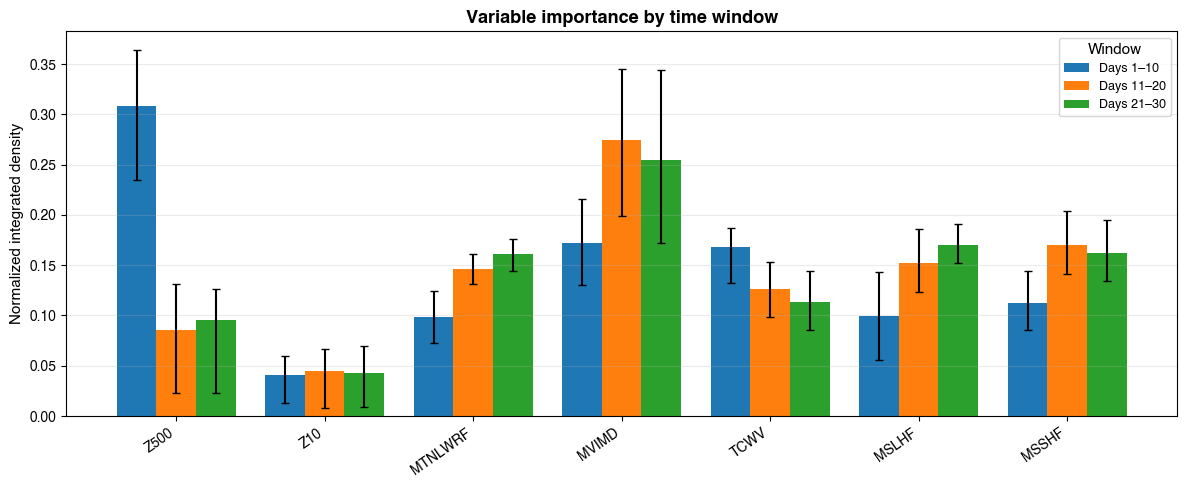

In [74]:
plot_window_importance_with_dispersion(
    df_keep,
    windows=("days_1_10", "days_11_20", "days_21_30"),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    dispersion="percentile",        # or "percentile"
    center="mean",           # or "median"
    figsize=(12, 5),
)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def lon0360_to_m180_180(lon):
    lon = np.asarray(lon, dtype=float) % 360.0
    return ((lon + 180.0) % 360.0) - 180.0


def plot_trace_st_spaghetti(
    ensemble_results,
    full_data_run,
    *,
    timeres_hours=24.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    title="TraCE-ST ensemble",
    cmap_name="viridis",
    alpha_line=0.18,
    alpha_dot=0.35,
    linewidth=0.9,
    markersize=16,
    event_lon=None,
    event_lat=None,
    event_label="Target point",
    show_legend=True,
    show_colorbar=True,
):
    """
    Plot all successful ensemble trajectories together.

    Parameters
    ----------
    ensemble_results : list of dict
        Each element should look like:
        {
            "success": bool,
            "centers": array-like (n_steps, 2),
            "parents": array-like (n_steps,),
            ...
        }

    full_data_run : xarray object
        Must contain coord 'var' if available.

    Notes
    -----
    - centers[:, 0] assumed lat
    - centers[:, 1] assumed lon (typically 0..360)
    - parents assumed 1-based indexing
    """
    successful = [r for r in ensemble_results if r.get("success", True)]
    if len(successful) == 0:
        raise ValueError("No successful ensemble members found.")

    if "var" in full_data_run.coords:
        var_names = [str(v) for v in full_data_run["var"].values]
    else:
        max_parent = max(
            int(np.nanmax(np.asarray(r["parents"], dtype=int)))
            for r in successful
            if r.get("parents") is not None and len(r["parents"]) > 0
        )
        var_names = [f"var{i+1}" for i in range(max_parent)]

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    max_steps = max(len(np.asarray(r["centers"])) for r in successful)
    hours_back_all = np.arange(max_steps) * float(timeres_hours)

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(hours_back_all)),
        vmax=float(np.nanmax(hours_back_all)),
    )

    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    geo = ccrs.PlateCarree()

    fig = plt.figure(figsize=(13, 8))
    ax = plt.axes(projection=proj)

    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.9, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False

    for res in successful:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)

        if len(centers) == 0:
            continue

        lats = centers[:, 0]
        lons = centers[:, 1] % 360.0
        steps = np.arange(len(lats))
        hours_back = steps * float(timeres_hours)

        ax.plot(
            lons,
            lats,
            "-",
            color="0.6",
            linewidth=linewidth,
            alpha=alpha_line,
            transform=geo,
            zorder=3,
        )

        p0 = np.clip(parents - 1, 0, len(var_names) - 1)
        parent_labels = np.array([var_names[i] for i in p0])

        for vname in var_names:
            mask = parent_labels == vname
            if not np.any(mask):
                continue
            ax.scatter(
                lons[mask],
                lats[mask],
                c=hours_back[mask],
                marker=marker_map[vname],
                s=markersize,
                alpha=alpha_dot,
                cmap=cmap,
                norm=norm,
                transform=geo,
                zorder=4,
            )

    ax.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=central_longitude))

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker="*",
            s=180,
            color="gold",
            edgecolor="k",
            linewidth=0.8,
            transform=geo,
            zorder=7,
            label=event_label,
        )

    if show_colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.02, shrink=0.35)
        cbar.set_label("Days back from target date")

    if show_legend:
        legend_handles = [
            Line2D(
                [0], [0],
                marker=marker_map[v],
                linestyle="None",
                markerfacecolor="k",
                markeredgecolor="k",
                markersize=8,
                label=v,
            )
            for v in var_names
        ]
        ax.legend(handles=legend_handles, title="Parent variable", loc="lower left")

    ax.set_title(title)
    plt.tight_layout()
    return fig, ax

In [76]:
def plot_trace_st_density_panels(
    ensemble_results,
    full_data_run,
    *,
    box_size,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(500, 300, 150),
    row_vmin=(0, 0, 0),
    normalize_rows=False,
    cmap="hot_r",
    figsize_per_panel=3.25,
    title="TraCE-ST trajectory density",
    cbar_labels=None,
    event_lon=None,
    event_lat=None,
    event_marker="*",
    event_color="gold",
    event_size=65,
):
    """
    Plot 3 x Nvar box-footprint density maps for one ensemble.

    Uses successful ensemble members only.
    """

    successful = [r for r in ensemble_results if r.get("success", True)]
    if len(successful) == 0:
        raise ValueError("No successful ensemble members found.")

    centers_ens = [np.asarray(r["centers"], dtype=float) for r in successful]
    parents_ens = [np.asarray(r["parents"], dtype=int) for r in successful]

    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)  # expected 0..360
    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)

    def density_by_variable_for_time_window_boxes(t_start, t_end):
        counts = np.zeros((n_vars, len(lats), len(lons)), dtype=np.float64)
        half = 0.5 * float(box_size)

        for centers, parents in zip(centers_ens, parents_ens):
            nT = min(len(centers), len(parents))
            a = max(0, int(t_start))
            b = min(nT, int(t_end))
            if b <= a:
                continue

            for (lat_c, lon_c), v in zip(centers[a:b], parents[a:b]):
                k = int(v) - 1
                if not (0 <= k < n_vars):
                    continue

                lat_c = float(lat_c)
                lon_c = float(lon_c) % 360.0

                lat_lo, lat_hi = lat_c - half, lat_c + half
                ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
                if ilats.size == 0:
                    continue

                lon_lo = (lon_c - half) % 360.0
                lon_hi = (lon_c + half) % 360.0
                if lon_lo <= lon_hi:
                    ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
                else:
                    ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]
                if ilons.size == 0:
                    continue

                counts[k][np.ix_(ilats, ilons)] += 1.0

        return counts

    n_rows = len(windows)
    if len(row_labels) != n_rows:
        raise ValueError("row_labels must have same length as windows")
    if len(row_vmax) != n_rows:
        raise ValueError("row_vmax must have same length as windows")
    if len(row_vmin) != n_rows:
        raise ValueError("row_vmin must have same length as windows")

    counts_rows = [density_by_variable_for_time_window_boxes(a, b) for (a, b) in windows]

    if normalize_rows:
        counts_rows_norm = []
        for counts in counts_rows:
            counts2 = counts.astype(float).copy()
            total = counts2.sum()
            if total > 0:
                counts2 /= total
            counts_rows_norm.append(counts2)
        counts_rows = counts_rows_norm

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]

    fig_w = max(14, figsize_per_panel * n_vars)
    fig_h = 3.15 * n_rows + 1.1
    fig, axes = plt.subplots(
        n_rows,
        n_vars,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=central_longitude)),
        squeeze=False,
        constrained_layout=False,
    )

    if cbar_labels is None:
        if normalize_rows:
            cbar_labels = ["Fraction of box-cover density"] * n_rows
        else:
            cbar_labels = ["Box-cover count across ensemble members"] * n_rows

    row_mappables = []

    for irow in range(n_rows):
        counts = counts_rows[irow]
        this_vmax = row_vmax[irow]
        this_vmin = row_vmin[irow]

        if this_vmax is None:
            vals = counts[np.isfinite(counts)]
            vals = vals[vals > 0]
            this_vmax = np.percentile(vals, 99.5) if vals.size else 1.0

        row_mesh = None

        for icol in range(n_vars):
            ax = axes[irow, icol]

            ax.set_facecolor("white")
            ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

            gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False

            ax.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=central_longitude))

            H = counts[icol][:, order]
            mesh = ax.pcolormesh(
                lon_plot,
                lats,
                H,
                transform=ccrs.PlateCarree(),
                shading="auto",
                vmin=this_vmin,
                vmax=this_vmax,
                cmap=cmap,
                zorder=1,
            )
            row_mesh = mesh

            if irow == 0:
                ax.set_title(var_names[icol], fontsize=12, fontweight="bold", pad=6)

            if icol == 0:
                ax.text(
                    -0.11, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            if event_lon is not None and event_lat is not None:
                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker=event_marker,
                    s=event_size,
                    color=event_color,
                    edgecolor="k",
                    linewidth=0.6,
                    transform=ccrs.PlateCarree(),
                    zorder=5,
                )

        row_mappables.append(row_mesh)

    fig.subplots_adjust(
        left=0.055,
        right=0.97,
        top=0.90,
        bottom=0.14,
        wspace=0.06,
        hspace=0.12,
    )

    for irow in range(n_rows):
        left = 0.32
        width = 0.40
        height = 0.016
        y_positions = [0.665, 0.395, 0.125]
        if n_rows == 3:
            y = y_positions[irow]
        else:
            y = 0.12 + (n_rows - 1 - irow) * (0.70 / max(1, n_rows - 1))

        cax = fig.add_axes([left, y, width, height])
        cb = fig.colorbar(row_mappables[irow], cax=cax, orientation="horizontal")
        cb.set_label(cbar_labels[irow], fontsize=10)
        cb.ax.tick_params(labelsize=9)

    if title is not None:
        fig.suptitle(title, fontsize=15, fontweight="bold", y=0.965)

    return fig, axes

In [77]:
def get_run_dir(run_id, out_root=OUT_ROOT):
    return Path(out_root) / f"run_{int(run_id):04d}"

def load_run_params(run_id, out_root=OUT_ROOT):
    run_dir = get_run_dir(run_id, out_root)
    with open(run_dir / "params.json", "r") as f:
        return json.load(f)

def load_run_summary(run_id, out_root=OUT_ROOT):
    run_dir = get_run_dir(run_id, out_root)
    with open(run_dir / "summary.json", "r") as f:
        return json.load(f)

def load_run_results(run_id, out_root=OUT_ROOT):
    run_dir = get_run_dir(run_id, out_root)
    with open(run_dir / "ensemble_results.pkl", "rb") as f:
        return pickle.load(f)

In [78]:
run_id = 1  # change this

params_sel = load_run_params(run_id)
summary_sel = load_run_summary(run_id)
results_sel = load_run_results(run_id)

print("Loaded run:", run_id)
print("n_requested:", summary_sel["n_requested"])
print("n_success:", summary_sel["n_success"])
print("n_failed:", summary_sel["n_failed"])

Loaded run: 1
n_requested: 100
n_success: 100
n_failed: 0


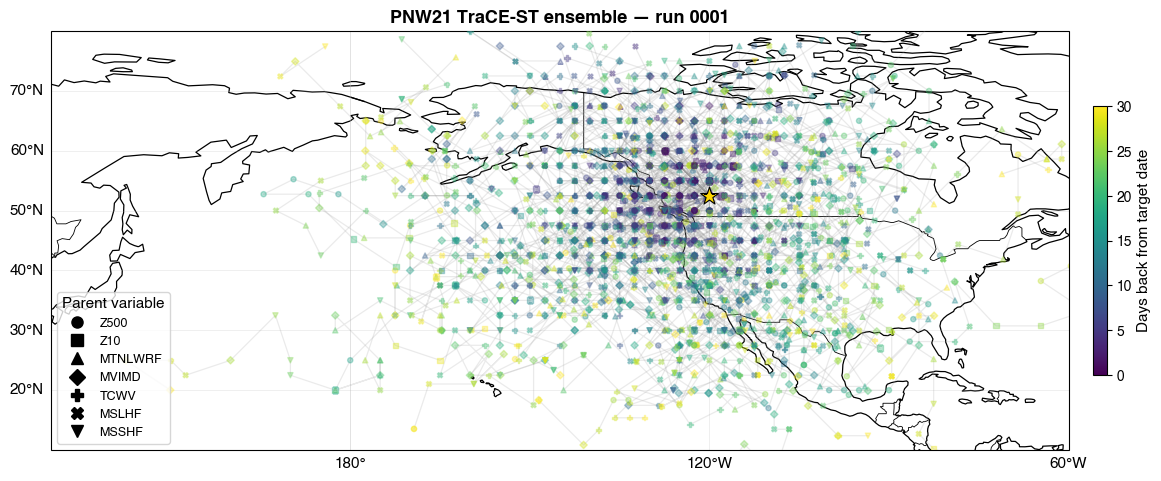

In [79]:
fig, ax = plot_trace_st_spaghetti(
    results_sel,
    full_data_run,
    timeres_hours=1,
    extent=(120, -50, 10, 80),
    title=f"PNW21 TraCE-ST ensemble — run {int(params_sel['run_id']):04d}",
    cmap_name="viridis",
    alpha_line=0.20,
    alpha_dot=0.35,
    linewidth=0.9,
    markersize=14,
    event_lon=240.0,
    event_lat=52.5,
)
plt.show()

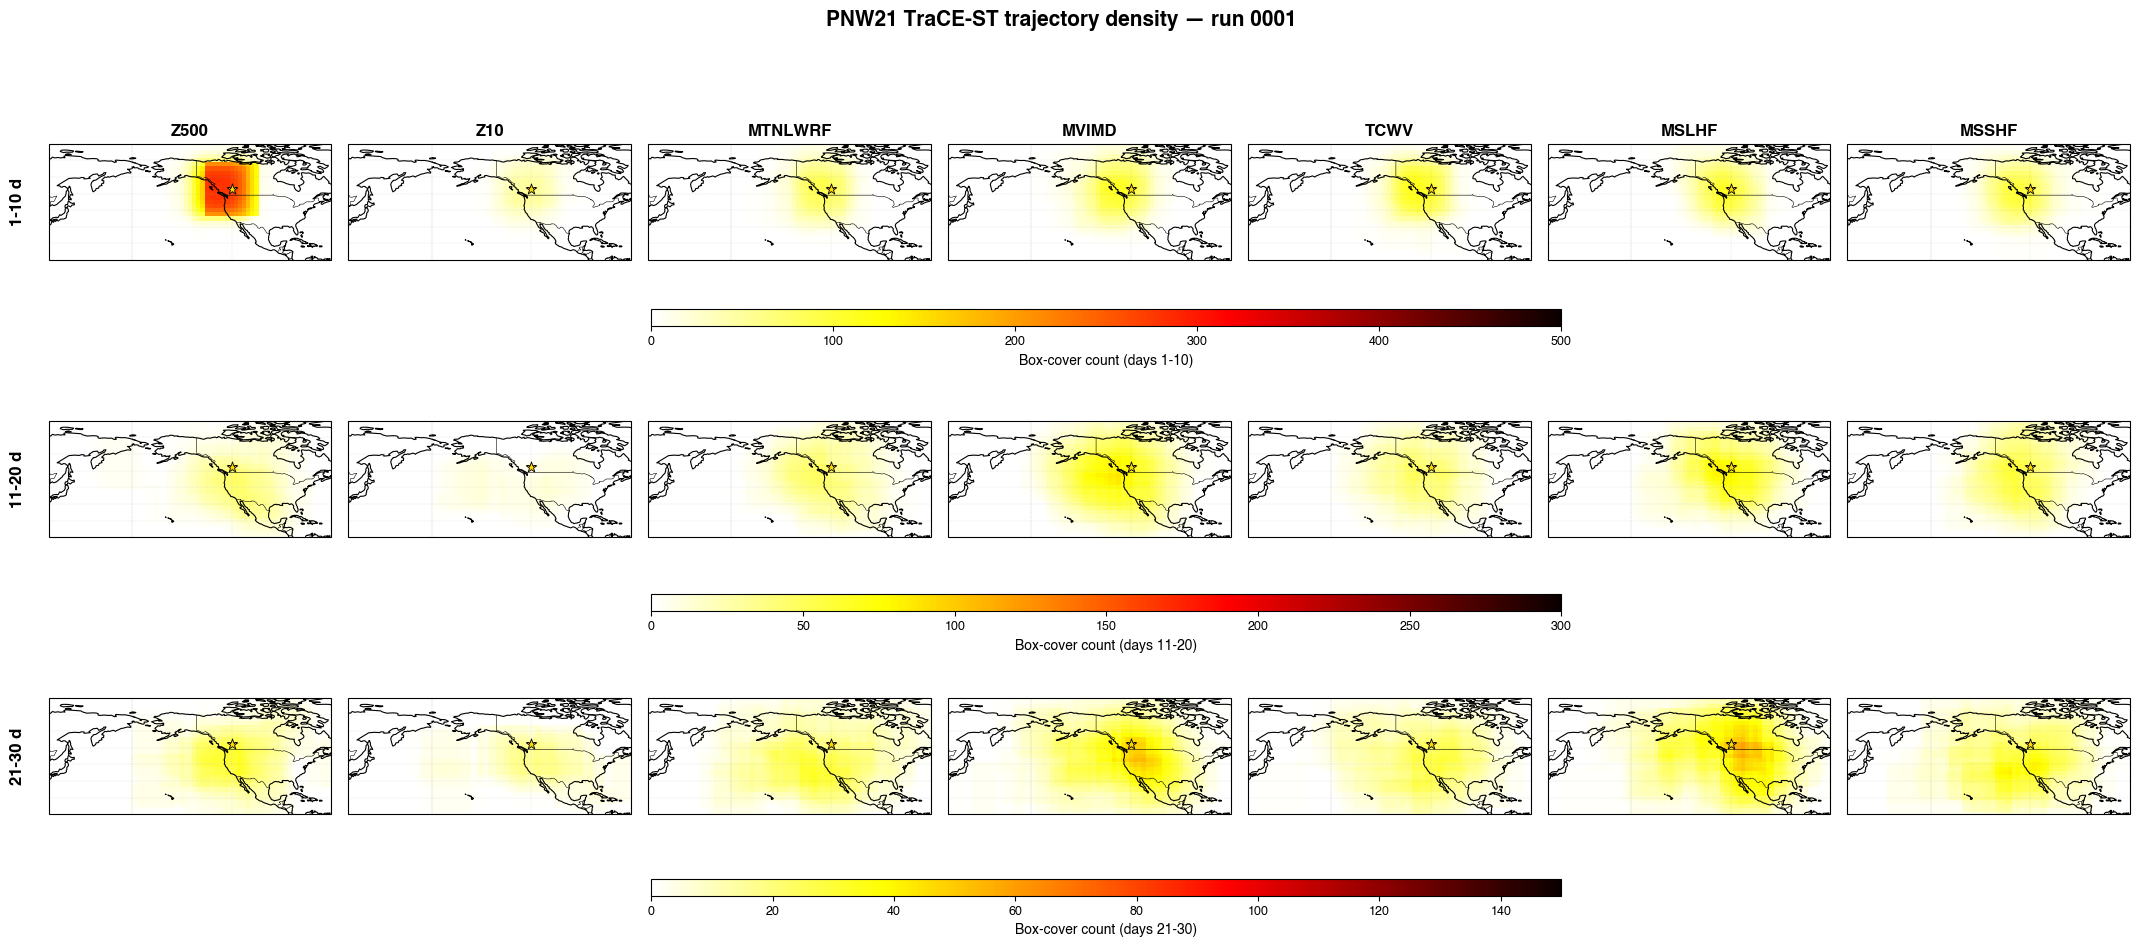

In [80]:
fig, axes = plot_trace_st_density_panels(
    results_sel,
    full_data_run,
    box_size=params_sel["box_size"],
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(500, 300, 150),
    row_vmin=(0, 0, 0),
    normalize_rows=False,
    cmap="hot_r",
    figsize_per_panel=3.25,
    event_lon=240.0,
    event_lat=52.5,
    title=f"PNW21 TraCE-ST trajectory density — run {int(params_sel['run_id']):04d}",
    cbar_labels=(
        "Box-cover count (days 1-10)",
        "Box-cover count (days 11-20)",
        "Box-cover count (days 21-30)",
    ),
)
plt.show()

In [81]:
# =========================================================
# Pool all successful ensemble members from kept runs,
# keeping the run-specific box_size attached to each member
# =========================================================
pooled_members = []

for run_id in df_keep.run_id.values:
    params_sel = load_run_params(run_id)
    summary_sel = load_run_summary(run_id)
    results_sel = load_run_results(run_id)

    box_size_sel = float(params_sel["box_size"])

    successful_sel = [r for r in results_sel if r.get("success", True)]

    for r in successful_sel:
        pooled_members.append({
            "run_id": int(run_id),
            "box_size": box_size_sel,
            "centers": np.asarray(r["centers"], dtype=float),
            "parents": np.asarray(r["parents"], dtype=int),
        })

    print(
        f"run {int(run_id):04d} | "
        f"box_size={box_size_sel} | "
        f"success {summary_sel['n_success']}/{summary_sel['n_requested']}"
    )

print("\nTotal kept runs:", len(df_keep))
print("Total pooled successful members:", len(pooled_members))

run 0001 | box_size=30.0 | success 100/100
run 0007 | box_size=35.0 | success 100/100
run 0009 | box_size=35.0 | success 100/100
run 0011 | box_size=35.0 | success 100/100
run 0012 | box_size=25.0 | success 100/100
run 0013 | box_size=35.0 | success 100/100
run 0014 | box_size=40.0 | success 100/100
run 0015 | box_size=30.0 | success 100/100
run 0016 | box_size=35.0 | success 100/100
run 0020 | box_size=40.0 | success 100/100
run 0021 | box_size=40.0 | success 100/100
run 0023 | box_size=20.0 | success 100/100
run 0025 | box_size=35.0 | success 100/100
run 0026 | box_size=25.0 | success 100/100
run 0028 | box_size=25.0 | success 100/100
run 0031 | box_size=35.0 | success 100/100
run 0032 | box_size=30.0 | success 100/100
run 0033 | box_size=40.0 | success 100/100
run 0035 | box_size=25.0 | success 100/100
run 0037 | box_size=25.0 | success 100/100
run 0040 | box_size=40.0 | success 100/100
run 0041 | box_size=25.0 | success 72/100
run 0042 | box_size=25.0 | success 100/100
run 0043 | b

In [82]:
import numpy as np


def density_by_variable_for_time_window_boxes_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
    t_start,   # inclusive
    t_end,     # exclusive
):
    """
    Compute density maps using the run-specific box_size for each pooled member.

    pooled_members: list of dicts with keys
        - centers
        - parents
        - box_size
    """
    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)  # assume 0..360
    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)

    counts = np.zeros((n_vars, len(lats), len(lons)), dtype=np.float64)

    for member in pooled_members:
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)
        half = 0.5 * float(member["box_size"])

        nT = min(len(centers), len(parents))
        a = max(0, int(t_start))
        b = min(nT, int(t_end))
        if b <= a:
            continue

        for (lat_c, lon_c), v in zip(centers[a:b], parents[a:b]):
            k = int(v) - 1
            if not (0 <= k < n_vars):
                continue

            lat_c = float(lat_c)
            lon_c = float(lon_c) % 360.0

            lat_lo, lat_hi = lat_c - half, lat_c + half
            ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
            if ilats.size == 0:
                continue

            lon_lo = (lon_c - half) % 360.0
            lon_hi = (lon_c + half) % 360.0
            if lon_lo <= lon_hi:
                ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
            else:
                ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]

            if ilons.size == 0:
                continue

            counts[k][np.ix_(ilats, ilons)] += 1.0

    return counts, var_names, lats, lons

In [83]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_pooled_density_windows_by_var_rows_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(None, None, None),
    row_vmin=(0, 0, 0),
    normalize_rows=False,
    cmap="hot_r",
    figsize_per_panel=3.25,
    title=None,
    cbar_labels=None,
    event_lon=None,
    event_lat=None,
    event_marker="*",
    event_color="gold",
    event_size=65,
):
    n_rows = len(windows)
    if len(row_labels) != n_rows:
        raise ValueError("row_labels must have same length as windows")
    if len(row_vmax) != n_rows:
        raise ValueError("row_vmax must have same length as windows")
    if len(row_vmin) != n_rows:
        raise ValueError("row_vmin must have same length as windows")

    counts_rows = []
    var_names = None
    lats = None
    lons = None

    for (a, b) in windows:
        counts, var_names, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
            pooled_members,
            full_data_run=full_data_run,
            t_start=a,
            t_end=b,
        )
        counts_rows.append(counts)

    if normalize_rows:
        counts_rows_norm = []
        for counts in counts_rows:
            counts2 = counts.astype(float).copy()
            total = counts2.sum()
            if total > 0:
                counts2 /= total
            counts_rows_norm.append(counts2)
        counts_rows = counts_rows_norm

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]

    n_vars = len(var_names)
    fig_w = max(14, figsize_per_panel * n_vars)
    fig_h = 3.15 * n_rows + 1.1
    fig, axes = plt.subplots(
        n_rows,
        n_vars,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=central_longitude)),
        squeeze=False,
        constrained_layout=False,
    )

    if cbar_labels is None:
        if normalize_rows:
            cbar_labels = ["Fraction of pooled density"] * n_rows
        else:
            cbar_labels = ["Box-cover count across pooled members"] * n_rows

    row_mappables = []

    for irow in range(n_rows):
        counts = counts_rows[irow]
        this_vmax = row_vmax[irow]
        this_vmin = row_vmin[irow]

        if this_vmax is None:
            vals = counts[np.isfinite(counts)]
            vals = vals[vals > 0]
            this_vmax = np.percentile(vals, 99.5) if vals.size else 1.0

        row_mesh = None

        for icol in range(n_vars):
            ax = axes[irow, icol]

            ax.set_facecolor("white")
            ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

            gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False

            ax.set_extent(
                extent,
                crs=ccrs.PlateCarree(central_longitude=central_longitude)
            )

            H = counts[icol][:, order]
            mesh = ax.pcolormesh(
                lon_plot,
                lats,
                H,
                transform=ccrs.PlateCarree(),
                shading="auto",
                vmin=this_vmin,
                vmax=this_vmax,
                cmap=cmap,
                zorder=1,
            )
            row_mesh = mesh

            if irow == 0:
                ax.set_title(var_names[icol], fontsize=12, fontweight="bold", pad=6)

            if icol == 0:
                ax.text(
                    -0.11, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            if event_lon is not None and event_lat is not None:
                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker=event_marker,
                    s=event_size,
                    color=event_color,
                    edgecolor="k",
                    linewidth=0.6,
                    transform=ccrs.PlateCarree(),
                    zorder=5,
                )

        row_mappables.append(row_mesh)

    fig.subplots_adjust(
        left=0.055,
        right=0.97,
        top=0.90,
        bottom=0.14,
        wspace=0.06,
        hspace=0.12,
    )

    for irow in range(n_rows):
        left = 0.32
        width = 0.40
        height = 0.016
        y_positions = [0.665, 0.395, 0.125]
        y = y_positions[irow] if n_rows == 3 else 0.12 + (n_rows - 1 - irow) * (0.70 / max(1, n_rows - 1))

        cax = fig.add_axes([left, y, width, height])
        cb = fig.colorbar(row_mappables[irow], cax=cax, orientation="horizontal")
        cb.set_label(cbar_labels[irow], fontsize=10)
        cb.ax.tick_params(labelsize=9)

    if title is not None:
        fig.suptitle(title, fontsize=15, fontweight="bold", y=0.965)

    return fig, axes

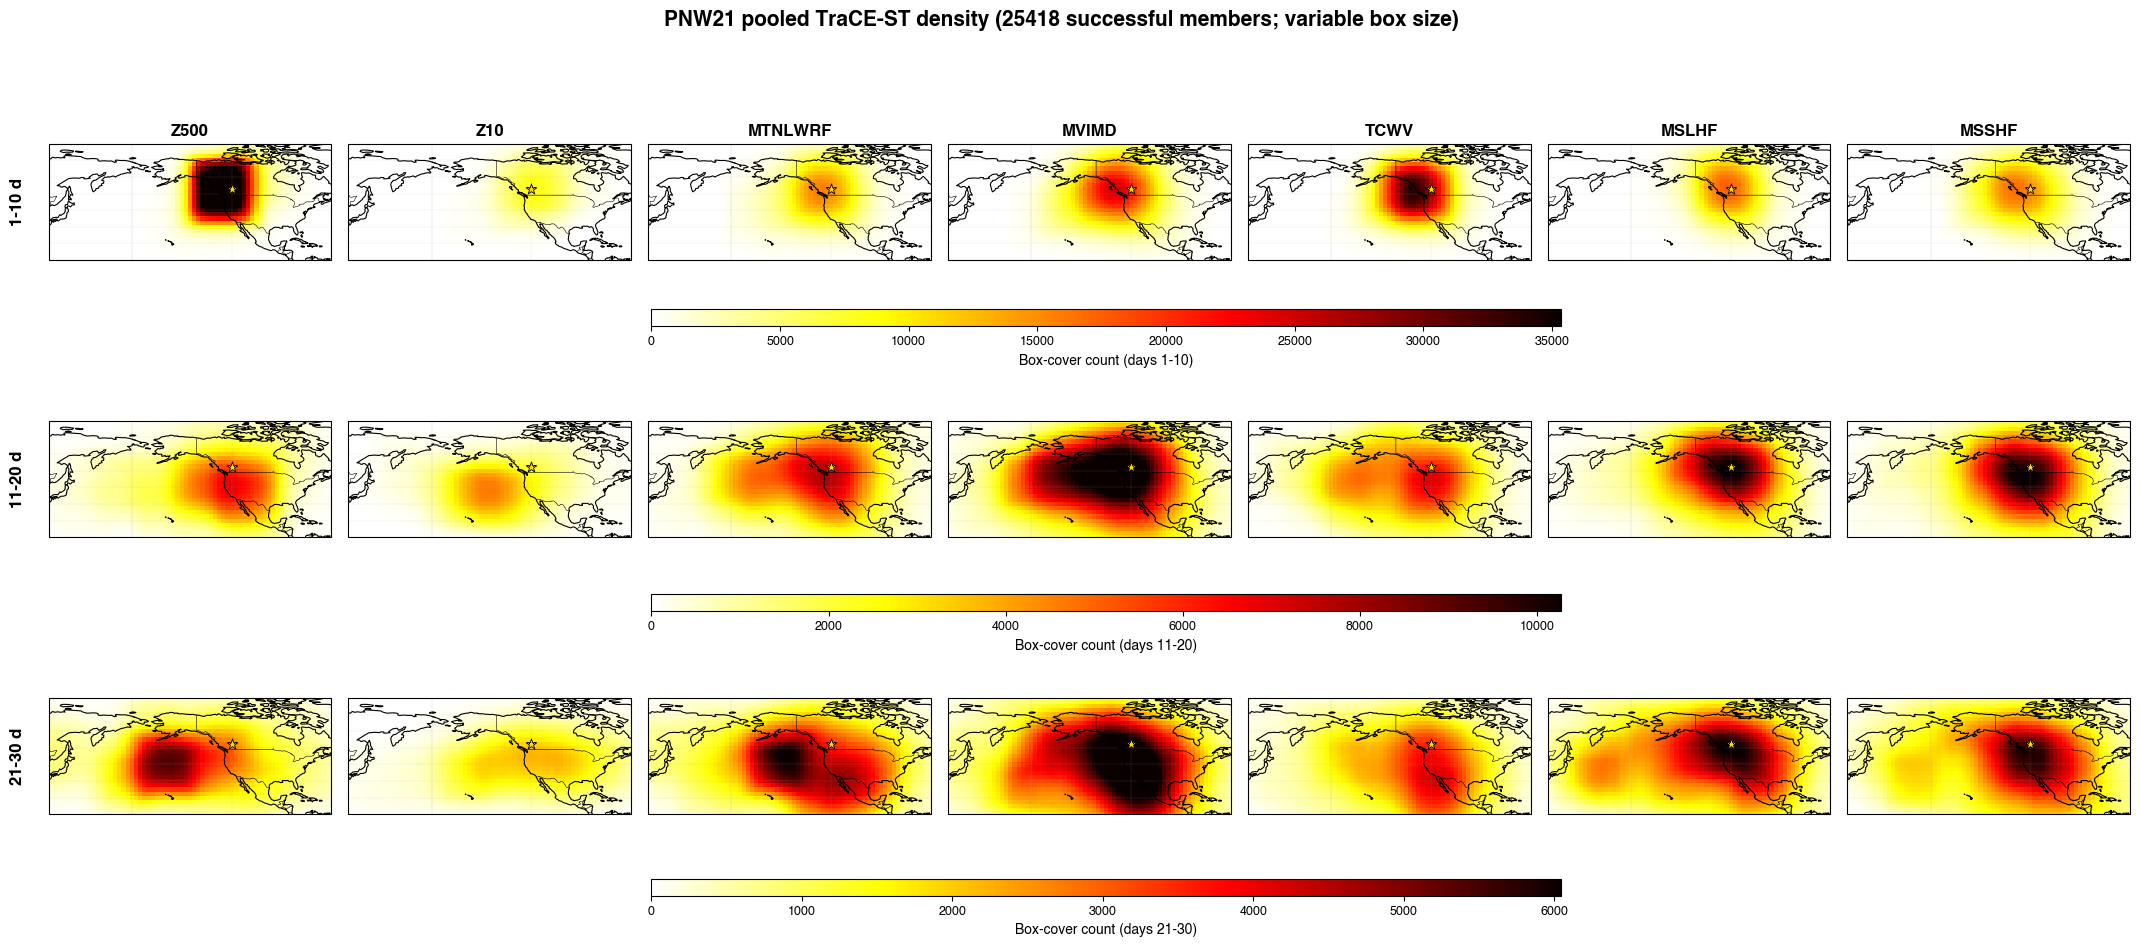

In [84]:
fig, axes = plot_pooled_density_windows_by_var_rows_variable_boxsize(
    pooled_members,
    full_data_run=full_data_run,
    windows=((1, 10), (11, 20), (21, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(None, None, None),
    row_vmin=(0, 0, 0),
    normalize_rows=False,
    cmap="hot_r",
    figsize_per_panel=3.25,
    event_lon=240.0,
    event_lat=52.5,
    event_marker="*",
    event_color="gold",
    event_size=65,
    title=f"PNW21 pooled TraCE-ST density ({len(pooled_members)} successful members; variable box size)",
    cbar_labels=(
        "Box-cover count (days 1-10)",
        "Box-cover count (days 11-20)",
        "Box-cover count (days 21-30)",
    ),
)
plt.show()

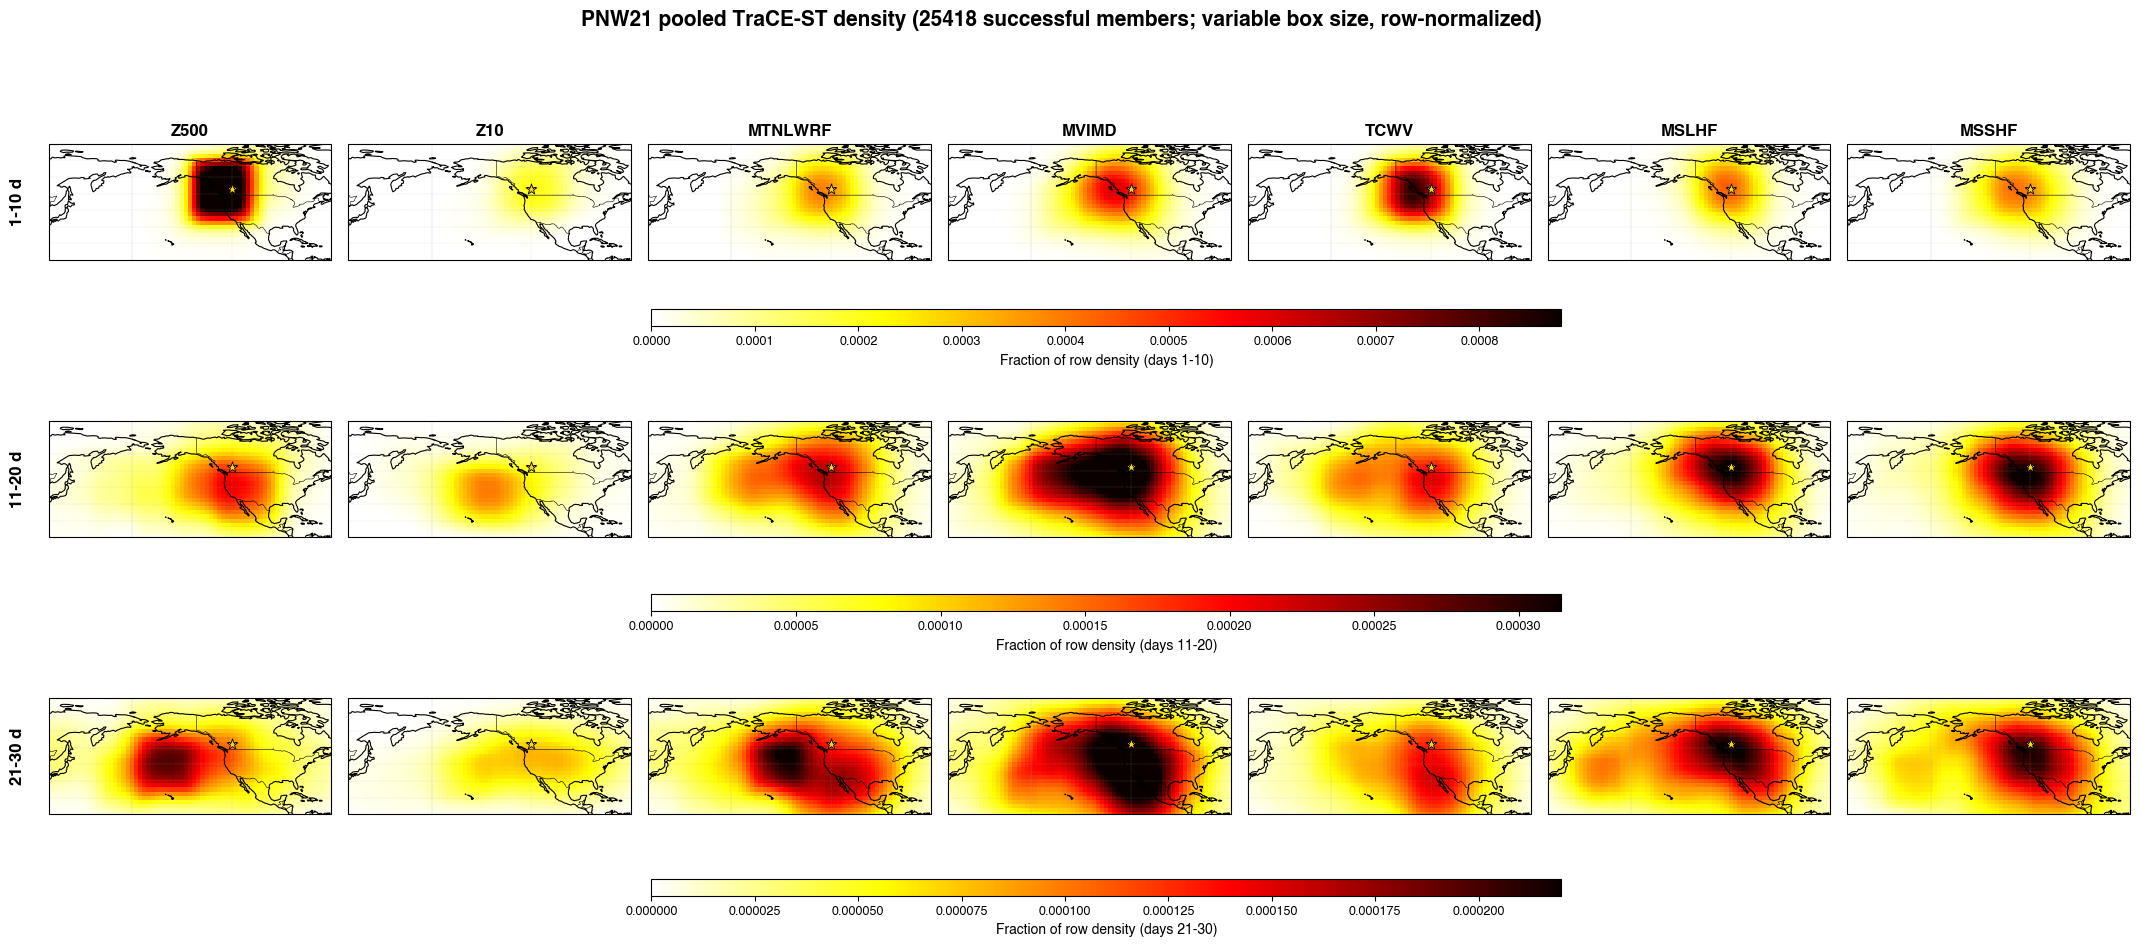

In [85]:
fig, axes = plot_pooled_density_windows_by_var_rows_variable_boxsize(
    pooled_members,
    full_data_run=full_data_run,
    windows=((1, 10), (11, 20), (21, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(None, None, None),
    row_vmin=(0, 0, 0),
    normalize_rows=True,
    cmap="hot_r",
    figsize_per_panel=3.25,
    event_lon=240.0,
    event_lat=52.5,
    event_marker="*",
    event_color="gold",
    event_size=65,
    title=f"PNW21 pooled TraCE-ST density ({len(pooled_members)} successful members; variable box size, row-normalized)",
    cbar_labels=(
        "Fraction of row density (days 1-10)",
        "Fraction of row density (days 11-20)",
        "Fraction of row density (days 21-30)",
    ),
)
plt.show()

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_window_mean_fields_by_var(
    full_data_run,
    *,
    date_end,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    timeres_days=1.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    cmap="RdBu_r",
    robust_percentile=99.0,
    symmetric=True,
    figsize_per_panel=3.25,
    title=None,
    cbar_label="Mean anomaly",
):
    """
    Plot mean fields for each variable and time window.

    Parameters
    ----------
    full_data_run : xr.DataArray
        Expected dims include time, var, lat/lon.
    date_end : str or datetime-like
        Target date corresponding to trajectory step 0.
    windows : tuple of (start, end)
        Window indices in the same convention as your trajectory plots:
        (0,10), (10,20), (20,30), etc.
        Each window is [start, end), inclusive-exclusive in step index.
    timeres_days : float
        Time resolution in days between steps.
    symmetric : bool
        If True, use symmetric color limits around zero for each variable.
    robust_percentile : float
        Percentile used to define variable-specific color limits.
    """

    # ----------------------------
    # Infer coordinate names
    # ----------------------------
    time_name = "time"
    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"

    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)
    n_rows = len(windows)

    if len(row_labels) != n_rows:
        raise ValueError("row_labels must have same length as windows")

    # ----------------------------
    # Find target time index
    # ----------------------------
    time_vals = pd.to_datetime(full_data_run[time_name].values)
    target_time = pd.Timestamp(date_end)

    # nearest time index
    idx_end = int(np.argmin(np.abs(time_vals - target_time)))
    matched_time = pd.Timestamp(time_vals[idx_end])

    print(f"Requested date_end: {target_time}")
    print(f"Matched time in full_data_run: {matched_time}")

    # ----------------------------
    # Precompute mean fields
    # ----------------------------
    lon_vals = np.asarray(full_data_run[lon_name].values, dtype=float)
    lon_pm = ((lon_vals + 180) % 360) - 180
    lon_order = np.argsort(lon_pm)
    lon_plot = lon_pm[lon_order]

    mean_fields = {}   # (irow, icol) -> 2D array
    var_limits = {}    # var_name -> (vmin, vmax)

    for icol, vname in enumerate(var_names):
        fields_this_var = []

        for irow, (a, b) in enumerate(windows):
            # trajectory step s corresponds to date_end - s * timeres_days
            step_offsets = np.arange(a, b, dtype=int)
            time_indices = idx_end - np.round(step_offsets * timeres_days).astype(int)

            valid = (time_indices >= 0) & (time_indices < full_data_run.sizes[time_name])
            time_indices = time_indices[valid]

            if len(time_indices) == 0:
                arr2d = np.full(
                    (full_data_run.sizes[lat_name], full_data_run.sizes[lon_name]),
                    np.nan,
                    dtype=float,
                )
            else:
                da_mean = (
                    full_data_run
                    .sel(var=vname)
                    .isel({time_name: time_indices})
                    .mean(time_name)
                )
                arr2d = np.asarray(da_mean.values, dtype=float)

            arr2d = arr2d[:, lon_order]
            mean_fields[(irow, icol)] = arr2d
            fields_this_var.append(arr2d)

        # variable-specific color limits across all rows
        vals = np.concatenate([f[np.isfinite(f)] for f in fields_this_var if np.isfinite(f).any()])
        if len(vals) == 0:
            vmin, vmax = -1.0, 1.0
        else:
            if symmetric:
                vmax = np.percentile(np.abs(vals), robust_percentile)
                vmin = -vmax
            else:
                vmin = np.percentile(vals, 100 - robust_percentile)
                vmax = np.percentile(vals, robust_percentile)
                if vmin == vmax:
                    vmax = vmin + 1e-6

        var_limits[vname] = (vmin, vmax)

    # ----------------------------
    # Plot
    # ----------------------------
    fig_w = max(14, figsize_per_panel * n_vars)
    fig_h = 3.15 * n_rows + 1.5

    fig, axes = plt.subplots(
        n_rows,
        n_vars,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(
            projection=ccrs.PlateCarree(central_longitude=central_longitude)
        ),
        squeeze=False,
        constrained_layout=False,
    )

    proj_data = ccrs.PlateCarree()
    col_mappables = [None] * n_vars

    for irow in range(n_rows):
        for icol, vname in enumerate(var_names):
            ax = axes[irow, icol]
            arr2d = mean_fields[(irow, icol)]
            vmin, vmax = var_limits[vname]

            ax.set_facecolor("white")
            ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

            gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False

            ax.set_extent(
                extent,
                crs=ccrs.PlateCarree(central_longitude=central_longitude)
            )

            mesh = ax.pcolormesh(
                lon_plot,
                np.asarray(full_data_run[lat_name].values, dtype=float),
                arr2d,
                transform=proj_data,
                shading="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                zorder=1,
            )

            if irow == 0:
                ax.set_title(vname, fontsize=12, fontweight="bold", pad=6)

            if icol == 0:
                ax.text(
                    -0.11, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            col_mappables[icol] = mesh

    # ----------------------------
    # Layout
    # ----------------------------
    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        top=0.90,
        bottom=0.15,
        wspace=0.06,
        hspace=0.12,
    )

    # ----------------------------
    # One colorbar per column
    # ----------------------------
    fig.canvas.draw()

    for icol in range(n_vars):
        ax_bottom = axes[-1, icol]
        pos = ax_bottom.get_position()

        cax = fig.add_axes([
            pos.x0,
            pos.y0 - 0.055,
            pos.width,
            0.018
        ])
        cb = fig.colorbar(col_mappables[icol], cax=cax, orientation="horizontal")
        cb.set_label(cbar_label, fontsize=9)
        cb.ax.tick_params(labelsize=8)

    if title is None:
        title = f"Mean fields by variable and window (ending {matched_time.date()})"

    fig.suptitle(title, fontsize=15, fontweight="bold", y=0.965)

    return fig, axes

Requested date_end: 2021-06-30 00:00:00
Matched time in full_data_run: 2021-06-30 00:00:00


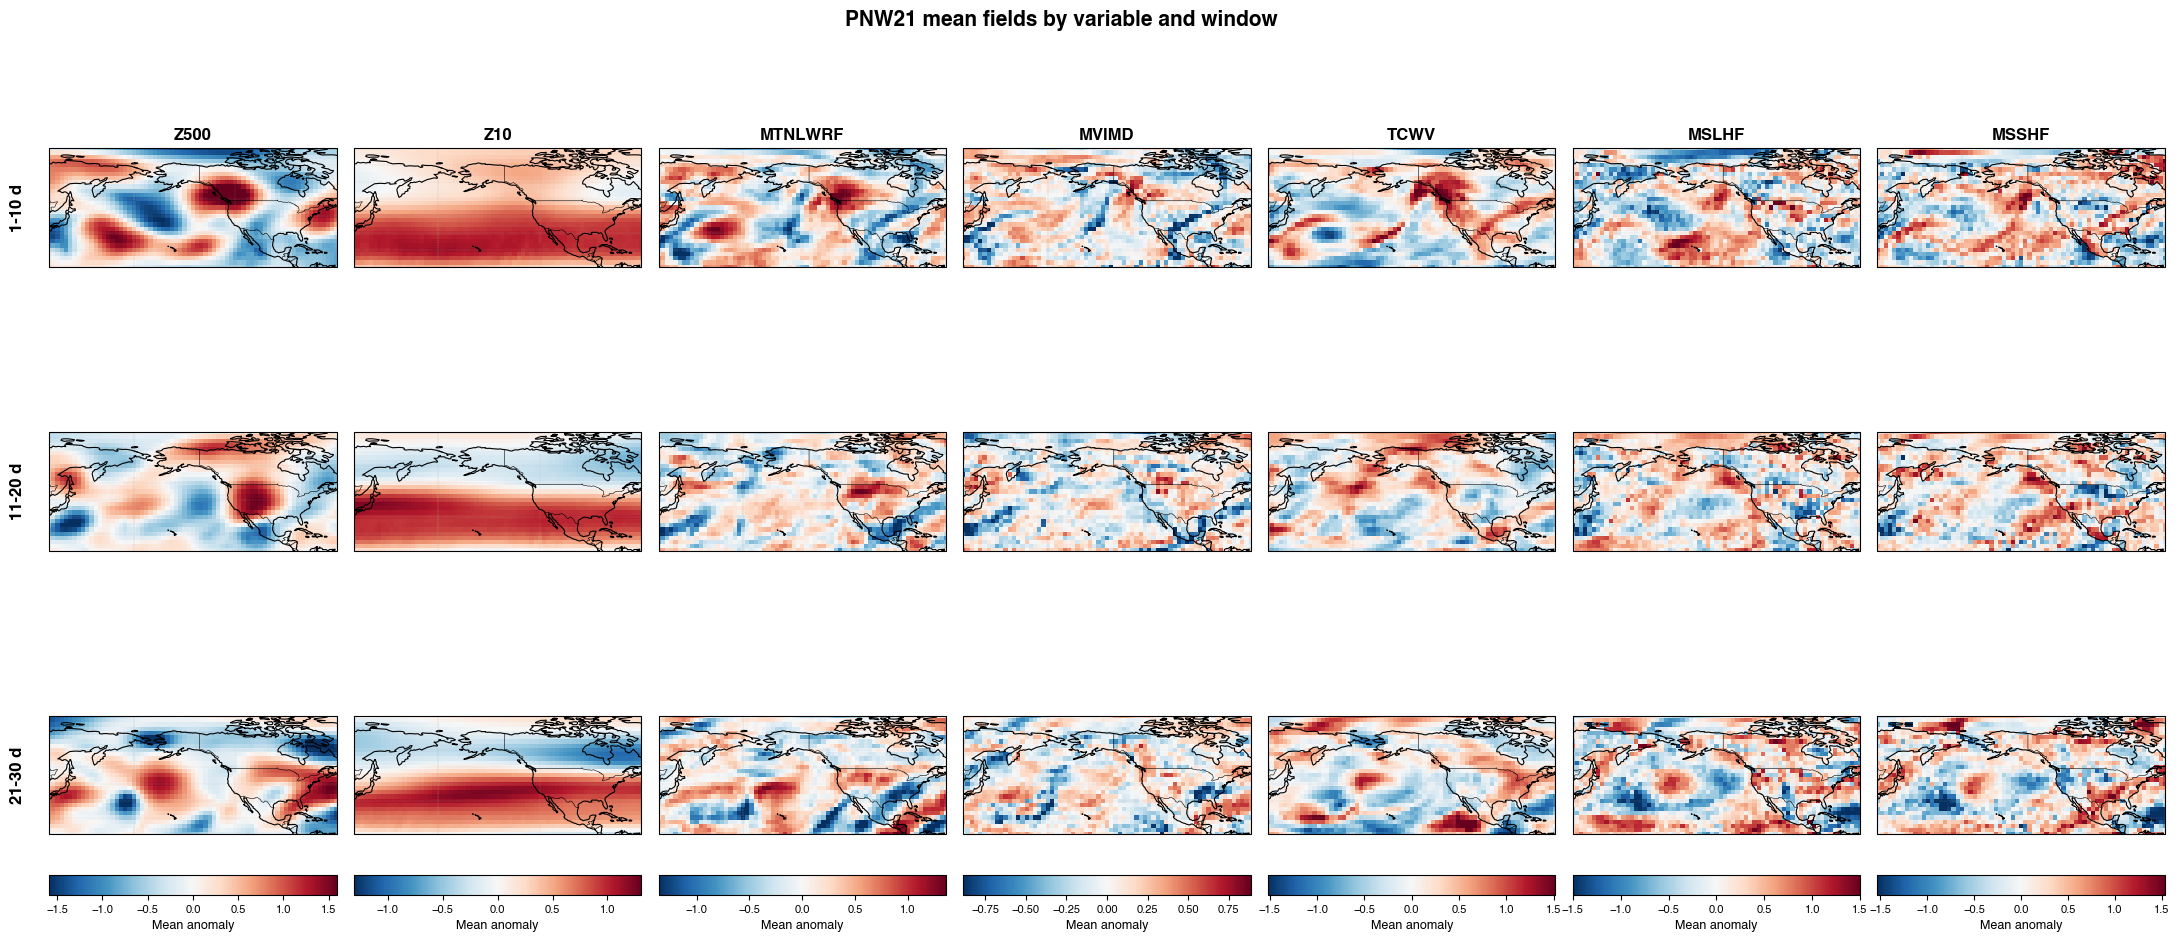

In [87]:
fig, axes = plot_window_mean_fields_by_var(
    full_data_run,
    date_end="2021-06-30",
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    timeres_days=1.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    cmap="RdBu_r",
    robust_percentile=99.0,
    symmetric=True,
    figsize_per_panel=3.25,
    title="PNW21 mean fields by variable and window",
    cbar_label="Mean anomaly",
)
plt.show()

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import random

def plot_random_trajectories(all_ensembles, n_samples=100, seed=42):
    """
    all_ensembles: list of ensembles
        each ensemble = list of trajectories
        each trajectory = dict or tuple with lat/lon arrays

    n_samples: number of trajectories to plot
    """

    random.seed(seed)

    # --- 1. Flatten all trajectories ---
    all_trajs = []
    for ens in all_ensembles:
        all_trajs.extend(ens)

    print(f"Total trajectories available: {len(all_trajs)}")

    # --- 2. Sample randomly ---
    n_samples = min(n_samples, len(all_trajs))
    sampled_trajs = random.sample(all_trajs, n_samples)

    # --- 3. Plot ---
    proj = ccrs.PlateCarree(central_longitude=180)

    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj)

    ax.coastlines()
    ax.set_global()

    # --- 4. Plot trajectories ---
    for traj in sampled_trajs:

        # --- adapt depending on your structure ---
        if isinstance(traj, dict):
            lats = traj["lat"]
            lons = traj["lon"]
        else:
            # assume tuple (lats, lons)
            lats, lons = traj

        ax.plot(
            lons,
            lats,
            transform=ccrs.PlateCarree(),
            linewidth=1,
            alpha=0.3,   # key for readability
        )

    plt.title(f"{n_samples} Randomly Sampled Trajectories")
    plt.tight_layout()
    plt.show()

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_random_pooled_trajectories(
    pooled_members,
    full_data_run,
    *,
    n_samples=100,
    seed=42,
    timeres_hours=24.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    title=None,
    cmap_name="viridis",
    alpha_line=0.22,
    alpha_dot=0.40,
    linewidth=1.0,
    markersize=18,
    event_lon=None,
    event_lat=None,
    event_label="Target point",
    show_legend=True,
    show_colorbar=True,
    annotate_run_ids=False,
):
    """
    Plot a random sample of trajectories drawn from pooled_members.

    Parameters
    ----------
    pooled_members : list of dict
        Expected keys:
            - "run_id"
            - "box_size"
            - "centers" : array-like, shape (n_steps, 2)
            - "parents" : array-like, shape (n_steps,)
    full_data_run : xarray object
        Used to recover variable names from full_data_run["var"].
    n_samples : int
        Number of pooled trajectories to sample without replacement.
    seed : int
        Random seed for reproducibility.
    annotate_run_ids : bool
        If True, annotate the first point of each sampled trajectory with run_id.
    """

    if len(pooled_members) == 0:
        raise ValueError("pooled_members is empty.")

    rng = np.random.default_rng(seed)
    n_samples = min(int(n_samples), len(pooled_members))
    sample_idx = rng.choice(len(pooled_members), size=n_samples, replace=False)
    sampled = [pooled_members[i] for i in sample_idx]

    var_names = list(full_data_run["var"].values)
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    max_steps = max(len(np.asarray(m["centers"])) for m in sampled)
    hours_back_all = np.arange(max_steps) * float(timeres_hours)

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(hours_back_all)),
        vmax=float(np.nanmax(hours_back_all)),
    )

    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    geo = ccrs.PlateCarree()

    fig = plt.figure(figsize=(13, 8))
    ax = plt.axes(projection=proj)

    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.9, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False

    for member in sampled:
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        if len(centers) == 0:
            continue

        lats = centers[:, 0]
        lons = centers[:, 1] % 360.0
        steps = np.arange(len(lats))
        hours_back = steps * float(timeres_hours)

        ax.plot(
            lons,
            lats,
            "-",
            color="0.55",
            linewidth=linewidth,
            alpha=alpha_line,
            transform=geo,
            zorder=3,
        )

        p0 = np.clip(parents - 1, 0, len(var_names) - 1)
        parent_labels = np.array([var_names[i] for i in p0])

        for vname in var_names:
            mask = parent_labels == vname
            if not np.any(mask):
                continue

            ax.scatter(
                lons[mask],
                lats[mask],
                c=hours_back[mask],
                marker=marker_map[vname],
                s=markersize,
                alpha=alpha_dot,
                cmap=cmap,
                norm=norm,
                transform=geo,
                zorder=4,
            )

        if annotate_run_ids:
            ax.text(
                lons[0],
                lats[0],
                str(member["run_id"]),
                fontsize=7,
                transform=geo,
                zorder=5,
            )

    ax.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=central_longitude))

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker="*",
            s=180,
            color="gold",
            edgecolor="k",
            linewidth=0.8,
            transform=geo,
            zorder=7,
            label=event_label,
        )

    if show_colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.02, shrink=0.35)
        cbar.set_label("Days back from target date")

    if show_legend:
        legend_handles = [
            Line2D(
                [0], [0],
                marker=marker_map[v],
                linestyle="None",
                markerfacecolor="k",
                markeredgecolor="k",
                markersize=8,
                label=v,
            )
            for v in var_names
        ]
        ax.legend(handles=legend_handles, title="Parent variable", loc="lower left")

    if title is None:
        title = f"PNW21 representative pooled trajectories ({n_samples} random members)"

    ax.set_title(title)
    plt.tight_layout()
    return fig, ax

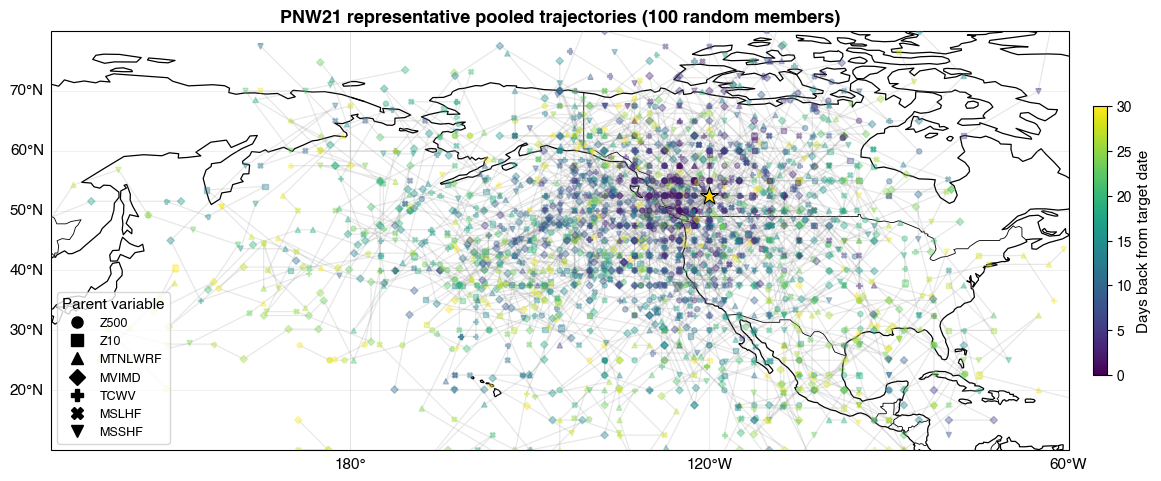

In [90]:
fig, ax = plot_random_pooled_trajectories(
    pooled_members,
    full_data_run,
    n_samples=100,          # or 50, 150, etc.
    seed=42,
    timeres_hours=1.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    title="PNW21 representative pooled trajectories (100 random members)",
    cmap_name="viridis",
    alpha_line=0.20,
    alpha_dot=0.35,
    linewidth=0.9,
    markersize=14,
    event_lon=240.0,
    event_lat=52.5,
    event_label="Target point",
)
plt.show()

# Fig4

In [91]:
import os
import matplotlib as mpl
import matplotlib.font_manager as fm
# ------------------------------------------------------------
# Font setup (Helvetica Regular + Bold)
# ------------------------------------------------------------
font_dir = "/glade/u/home/jhayron/Causality_CaStLe/PaperCausalBTs/Helvetica"

regular_font = os.path.join(font_dir, "Helvetica.ttf")
bold_font = os.path.join(font_dir, "Helvetica-Bold.ttf")

if os.path.exists(regular_font):
    fm.fontManager.addfont(regular_font)

if os.path.exists(bold_font):
    fm.fontManager.addfont(bold_font)

mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams["font.weight"] = "regular"

mpl.rcParams.update({
    # --------------------------------------------------
    # FONT FAMILY
    # --------------------------------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # --------------------------------------------------
    # WEIGHTS
    # --------------------------------------------------
    "font.weight": "regular",
    "axes.titleweight": "bold",
    "axes.labelweight": "regular",

    # --------------------------------------------------
    # FONT SIZES (optional but recommended)
    # --------------------------------------------------
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,

    # --------------------------------------------------
    # IMPORTANT: MATH TEXT → match Helvetica
    # --------------------------------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",   # ← THIS fixes the warning

    # --------------------------------------------------
    # PDF / VECTOR EXPORT (VERY IMPORTANT FOR PAPERS)
    # --------------------------------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

mpl.rcParams.update({

    # -------------------------
    # FONT FAMILY
    # -------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # -------------------------
    # BASE SIZE (master control)
    # -------------------------
    "font.size": 11,

    # -------------------------
    # TITLES
    # -------------------------
    "axes.titlesize": 13,
    "axes.titleweight": "bold",

    # -------------------------
    # AXIS LABELS
    # -------------------------
    "axes.labelsize": 11,

    # -------------------------
    # TICKS
    # -------------------------
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # -------------------------
    # LEGENDS
    # -------------------------
    "legend.fontsize": 9,

    # -------------------------
    # COLORBAR
    # -------------------------
    "axes.labelweight": "regular",

    # -------------------------
    # MATH TEXT (critical)
    # -------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",

    # -------------------------
    # VECTOR EXPORT
    # -------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================================================
# Labels
# =========================================================
VAR_LABELS_PNW = {
    "Z500": "Z500",
    "Z10": "Z10",
    "MTNLWRF": "OLR",
    "MVIMD": "VIMD",
    "TCWV": "TCWV",
    "MSLHF": "LHF",
    "MSSHF": "SHF",
}


# =========================================================
# Basic helpers
# =========================================================
def lon0360_to_m180_180(lon):
    lon = np.asarray(lon, dtype=float) % 360.0
    return ((lon + 180.0) % 360.0) - 180.0


def _infer_lat_lon_names(full_data_run):
    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"
    return lat_name, lon_name


def _style_geo_ax(ax, extent, central_longitude=180, add_grid=True):
    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    ax.set_extent(extent, crs=proj)
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

    if add_grid:
        gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False


# =========================================================
# Density helpers
# =========================================================
def density_by_variable_for_time_window_boxes_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
    t_start,
    t_end,
):
    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)
    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)

    counts = np.zeros((n_vars, len(lats), len(lons)), dtype=np.float64)

    for member in pooled_members:
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)
        half = 0.5 * float(member["box_size"])

        nT = min(len(centers), len(parents))
        a = max(0, int(t_start))
        b = min(nT, int(t_end))
        if b <= a:
            continue

        for (lat_c, lon_c), v in zip(centers[a:b], parents[a:b]):
            k = int(v) - 1
            if not (0 <= k < n_vars):
                continue

            lat_c = float(lat_c)
            lon_c = float(lon_c) % 360.0

            lat_lo, lat_hi = lat_c - half, lat_c + half
            ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
            if ilats.size == 0:
                continue

            lon_lo = (lon_c - half) % 360.0
            lon_hi = (lon_c + half) % 360.0
            if lon_lo <= lon_hi:
                ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
            else:
                ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]
            if ilons.size == 0:
                continue

            counts[k][np.ix_(ilats, ilons)] += 1.0

    return counts, var_names, lats, lons


def total_density_all_steps_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
):
    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)
    counts = np.zeros((len(lats), len(lons)), dtype=np.float64)

    for member in pooled_members:
        centers = np.asarray(member["centers"], dtype=float)
        half = 0.5 * float(member["box_size"])

        for (lat_c, lon_c) in centers:
            lat_c = float(lat_c)
            lon_c = float(lon_c) % 360.0

            lat_lo, lat_hi = lat_c - half, lat_c + half
            ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
            if ilats.size == 0:
                continue

            lon_lo = (lon_c - half) % 360.0
            lon_hi = (lon_c + half) % 360.0
            if lon_lo <= lon_hi:
                ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
            else:
                ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]
            if ilons.size == 0:
                continue

            counts[np.ix_(ilats, ilons)] += 1.0

    return counts, lats, lons


# =========================================================
# Variable relevance by run
# =========================================================
def compute_variable_importance_by_run(
    pooled_members,
    *,
    full_data_run,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
):
    var_names = [str(v) for v in full_data_run["var"].values]

    by_run = {}
    for member in pooled_members:
        by_run.setdefault(int(member["run_id"]), []).append(member)

    out = {label: [] for label in window_labels}

    for run_id, members in by_run.items():
        for (a, b), label in zip(windows, window_labels):
            counts, _, _, _ = density_by_variable_for_time_window_boxes_variable_boxsize(
                members,
                full_data_run=full_data_run,
                t_start=a,
                t_end=b,
            )
            integrated = counts.sum(axis=(1, 2)).astype(float)
            total = integrated.sum()
            norm = integrated / total if total > 0 else np.full(len(var_names), np.nan)
            out[label].append(norm)

    for label in window_labels:
        out[label] = np.asarray(out[label], dtype=float)

    return out, var_names


# =========================================================
# Panel A
# =========================================================
def draw_panel_representative_trajectories(
    ax,
    pooled_members,
    full_data_run,
    *,
    n_samples=100,
    seed=42,
    timeres_hours=24.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    cmap_name="cool_r",
    alpha_line=0.18,
    alpha_dot=0.40,
    linewidth=0.8,
    markersize=18,   # increased again
    event_lon=None,
    event_lat=None,
):
    rng = np.random.default_rng(seed)
    n_samples = min(int(n_samples), len(pooled_members))
    sample_idx = rng.choice(len(pooled_members), size=n_samples, replace=False)
    sampled = [pooled_members[i] for i in sample_idx]

    var_names = [str(v) for v in full_data_run["var"].values]
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    max_steps = max(len(np.asarray(m["centers"])) for m in sampled)
    days_back_all = np.arange(max_steps) * (float(timeres_hours) / 24.0)

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(days_back_all)),
        vmax=float(np.nanmax(days_back_all)),
    )

    geo = ccrs.PlateCarree()
    _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=False)

    for member in sampled:
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        if len(centers) == 0:
            continue

        lats = centers[:, 0]
        lons = centers[:, 1] % 360.0
        steps = np.arange(len(lats))
        days_back = steps * (float(timeres_hours) / 24.0)

        ax.plot(
            lons,
            lats,
            "-",
            color="k",
            linewidth=linewidth,
            alpha=alpha_line,
            transform=geo,
            zorder=2,
        )

        p0 = np.clip(parents - 1, 0, len(var_names) - 1)
        parent_labels = np.array([var_names[i] for i in p0])

        for vname in var_names:
            mask = parent_labels == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0]#[::2]
            ax.scatter(
                lons[idx],
                lats[idx],
                c=days_back[idx],
                cmap=cmap,
                norm=norm,
                marker=marker_map[vname],
                s=markersize,
                alpha=alpha_dot,
                edgecolor="none",
                transform=geo,
                zorder=3,
            )

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker="*",
            s=130,
            color="gold",
            edgecolor="k",
            linewidth=0.7,
            transform=geo,
            zorder=5,
        )

    return norm, cmap, marker_map


# =========================================================
# Panel B
# =========================================================
def draw_panel_total_density(
    ax,
    pooled_members,
    full_data_run,
    *,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    cmap="hot_r",
    vmax_percentile=99.5,
    event_lon=None,
    event_lat=None,
):
    counts_total, lats, lons = total_density_all_steps_variable_boxsize(
        pooled_members,
        full_data_run=full_data_run,
    )

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]
    H = counts_total[:, order]

    geo = ccrs.PlateCarree()
    _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

    vals = H[np.isfinite(H)]
    vals = vals[vals > 0]
    vmax = np.percentile(vals, vmax_percentile) if vals.size else 1.0

    mesh = ax.pcolormesh(
        lon_plot,
        lats,
        H,
        transform=geo,
        shading="auto",
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        alpha=0.85,
        zorder=1,
        rasterized=True
    )

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            ((event_lon + 180) % 360) - 180,
            event_lat,
            marker="*",
            s=130,
            color="gold",
            edgecolor="k",
            linewidth=0.7,
            transform=geo,
            zorder=5,
        )

    return mesh


# =========================================================
# Panel C
# =========================================================
def draw_panel_variable_importance(
    ax,
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    p_lo=10,
    p_hi=90,
):
    imp_by_run, var_names = compute_variable_importance_by_run(
        pooled_members,
        full_data_run=full_data_run,
        windows=windows,
        window_labels=window_labels,
    )

    x = np.arange(len(var_names))
    width = 0.24

    # colors chosen to resemble cool_r progression
    colors = ["#b12ad4", "#6a7fdc", "#63d4de"]  # purple, blue, cyan

    for i, label in enumerate(window_labels):
        arr = imp_by_run[label]
        med = np.nanmedian(arr, axis=0)
        lo = np.nanpercentile(arr, p_lo, axis=0)
        hi = np.nanpercentile(arr, p_hi, axis=0)
        yerr = np.vstack([med - lo, hi - med])

        ax.bar(
            x + (i - 1) * width,
            med,
            width=width,
            color=colors[i],
            label=label,
            alpha=0.95,
            yerr=yerr,
            ecolor="k",
            capsize=3,
            linewidth=0.8,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([VAR_LABELS_PNW.get(v, v) for v in var_names], rotation=35, ha="right")
    ax.set_ylabel("Normalized integrated density",fontsize=11)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=True, fontsize=9)
    ax.set_ylim(bottom=0)

def draw_panel_variable_importance_boxplots(
    ax,
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
):
    imp_by_run, var_names = compute_variable_importance_by_run(
        pooled_members,
        full_data_run=full_data_run,
        windows=windows,
        window_labels=window_labels,
    )

    x = np.arange(len(var_names), dtype=float)
    offsets = np.array([-0.26, 0.0, 0.26])
    width = 0.22

    colors = ["#b12ad4", "#6a7fdc", "#63d4de"]  # purple, blue, cyan

    legend_handles = []

    for i, label in enumerate(window_labels):
        arr = np.asarray(imp_by_run[label], dtype=float)   # shape: (n_runs, n_vars)

        data_i = []
        pos_i = []
        for j in range(len(var_names)):
            vals = arr[:, j]
            vals = vals[np.isfinite(vals)]
            data_i.append(vals)
            pos_i.append(x[j] + offsets[i])

        bp = ax.boxplot(
            data_i,
            positions=pos_i,
            widths=width,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color="0.15", linewidth=1.4),
            whiskerprops=dict(color="0.2", linewidth=1.0),
            capprops=dict(color="0.2", linewidth=1.0),
            boxprops=dict(linewidth=1.0, color="0.2"),
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(colors[i])
            patch.set_edgecolor(colors[i])
            patch.set_alpha(0.38)

        legend_handles.append(
            Line2D([0], [0], color=colors[i], lw=6, alpha=0.6, label=label)
        )

    ax.set_xticks(x)
    ax.set_xticklabels([VAR_LABELS_PNW.get(v, v) for v in var_names], rotation=35, ha="right")
    ax.set_ylabel("Normalized integrated density", fontsize=11)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(handles=legend_handles, frameon=True, fontsize=9)
    ax.set_ylim(bottom=0)


# =========================================================
# Panel D
# =========================================================
def draw_panel_density_windows_by_var(
    fig,
    gs_sub,
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1–10 d", "11–20 d", "21–30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(None, None, None),
    row_vmin=(0, 0, 0),
    normalize_rows=True,
    cmap="hot_r",
    event_lon=None,
    event_lat=None,
):
    var_names = [str(v) for v in full_data_run["var"].values]
    n_rows = len(windows)
    n_vars = len(var_names)

    counts_rows = []
    lats = None
    lons = None

    for (a, b) in windows:
        counts, _, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
            pooled_members,
            full_data_run=full_data_run,
            t_start=a,
            t_end=b,
        )
        counts_rows.append(counts)

    if normalize_rows:
        counts_rows_norm = []
        for counts in counts_rows:
            counts2 = counts.astype(float).copy()
            total = counts2.sum()
            if total > 0:
                counts2 /= total
            counts_rows_norm.append(counts2)
        counts_rows = counts_rows_norm

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]

    geo = ccrs.PlateCarree()
    proj = ccrs.PlateCarree(central_longitude=central_longitude)

    axes = np.empty((n_rows, n_vars), dtype=object)
    row_mappables = []

    for irow in range(n_rows):
        counts = counts_rows[irow]
        this_vmax = row_vmax[irow]
        this_vmin = row_vmin[irow]

        if this_vmax is None:
            vals = counts[np.isfinite(counts)]
            vals = vals[vals > 0]
            this_vmax = np.percentile(vals, 99.5) if vals.size else 1.0

        row_mesh = None

        for icol in range(n_vars):
            ax = fig.add_subplot(gs_sub[irow, icol], projection=proj)
            axes[irow, icol] = ax

            _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

            H = counts[icol][:, order]
            mesh = ax.pcolormesh(
                lon_plot,
                lats,
                H,
                transform=geo,
                shading="auto",
                vmin=this_vmin,
                vmax=this_vmax,
                cmap=cmap,
                zorder=1,
                rasterized=True
            )
            row_mesh = mesh

            if irow == 0:
                ax.set_title(VAR_LABELS_PNW.get(var_names[icol], var_names[icol]),
                             fontsize=11, fontweight="bold", pad=5)

            if icol == 0:
                ax.text(
                    -0.12, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=11,
                    fontweight="bold",
                )

            if event_lon is not None and event_lat is not None:
                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker="*",
                    s=38,
                    color="gold",
                    edgecolor="k",
                    linewidth=0.4,
                    transform=geo,
                    zorder=5,
                )

        row_mappables.append(row_mesh)

    return axes, row_mappables


# =========================================================
# Main figure
# =========================================================
def plot_trace_st_pnw_main_figure(
    pooled_members,
    full_data_run,
    *,
    n_rep_traj=100,
    seed=42,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1–10 d", "11–20 d", "21–30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    event_lon=None,
    event_lat=None,
    p_lo=10,
    p_hi=90,
):
    proj = ccrs.PlateCarree(central_longitude=central_longitude)

    fig = plt.figure(figsize=(16, 10))
    outer = gridspec.GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[0.90, 1.60],
        hspace=0.33,
    )

    # -------------------------
    # Top row with shorter C
    # -------------------------
    gs_top = gridspec.GridSpecFromSubplotSpec(
        2, 3,
        subplot_spec=outer[0],
        height_ratios=[0.78, 0.22],
        width_ratios=[1., 1., 1],
        hspace=0.12,
        wspace=0.18,
    )

    axA = fig.add_subplot(gs_top[0, 0], projection=proj)
    axB = fig.add_subplot(gs_top[0, 1], projection=proj)
    axC = fig.add_subplot(gs_top[:, 2])

    # Placeholder axes for colorbars under A and B
    axA_cb = fig.add_subplot(gs_top[1, 0])
    axB_cb = fig.add_subplot(gs_top[1, 1])
    axA_cb.axis("off")
    axB_cb.axis("off")

    # A
    lag_norm, lag_cmap, marker_map = draw_panel_representative_trajectories(
        axA,
        pooled_members,
        full_data_run,
        n_samples=n_rep_traj,
        seed=seed,
        timeres_hours=24.0,
        extent=extent,
        central_longitude=central_longitude,
        cmap_name="cool_r",
        alpha_line=0.18,
        alpha_dot=0.4,
        linewidth=0.8,
        markersize=25,
        event_lon=event_lon,
        event_lat=event_lat,
    )
    axA.set_title("A. Representative trajectories", loc="left", fontsize=14, fontweight="bold")

    # B
    mesh_total = draw_panel_total_density(
        axB,
        pooled_members,
        full_data_run,
        extent=extent,
        central_longitude=central_longitude,
        cmap="hot_r",
        vmax_percentile=99.5,
        event_lon=event_lon,
        event_lat=event_lat,
    )
    axB.set_title("B. Density of trajectories", loc="left", fontsize=14, fontweight="bold")

    # C
    draw_panel_variable_importance_boxplots(
        axC,
        pooled_members,
        full_data_run,
        windows=windows,
        window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    )
    axC.set_title("C. Variable relevance over time", loc="left", fontsize=14, fontweight="bold")

    # -------------------------
    # Bottom block
    # -------------------------
    gs_bottom = gridspec.GridSpecFromSubplotSpec(
        3, len(full_data_run["var"]),
        subplot_spec=outer[1],
        wspace=0.05,
        hspace=0.50,   # increased again
    )

    axesD, row_mappables = draw_panel_density_windows_by_var(
        fig,
        gs_bottom,
        pooled_members,
        full_data_run,
        windows=windows,
        row_labels=row_labels,
        extent=extent,
        central_longitude=central_longitude,
        row_vmax=(6e4, 1.6e4, 0.9e4),
        row_vmin=(0, 0, 0),
        normalize_rows=False,
        cmap="hot_r",
        event_lon=event_lon,
        event_lat=event_lat,
    )

    # D title (manual position)
    fig.text(
        0.11, 0.57,
        "D. Variable-specific densities by window",
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
    )

    # =====================================================
    # MANUAL legend + colorbar positions
    # =====================================================

    var_names = [str(v) for v in full_data_run["var"].values]
    legend_handles = [
        Line2D([0], [0], marker=marker_map[v], linestyle="None",
               markerfacecolor="k", markeredgecolor="k",
               markersize=7, label=VAR_LABELS_PNW.get(v, v))
        for v in var_names
    ]
    legend_handles += [
        Line2D([0], [0], marker="*", color="gold", markeredgecolor="k",
               linestyle="None", markersize=10, label="Target point"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0.135, 0.7),
        ncol=3,
        frameon=True,
        fontsize=10,
        title="Parent variable / markers",
        title_fontsize=11,
        columnspacing=1.5,
        handletextpad=0.6,
    )

    # A colorbar
    cax_lag = fig.add_axes([0.355, 0.72, 0.007, 0.15])
    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="vertical")
    cb_lag.set_label("Days back from target", fontsize=12)
    cb_lag.ax.tick_params(labelsize=10)

    # B colorbar
    cax_den = fig.add_axes([0.435, 0.67, 0.15, 0.012])
    cb_den = fig.colorbar(mesh_total, cax=cax_den, orientation="horizontal")
    cb_den.set_label("Total density", fontsize=12)
    cb_den.ax.tick_params(labelsize=10)

    from matplotlib.ticker import ScalarFormatter
    
    # D row 1 colorbar
    cax_row1 = fig.add_axes([0.40, 0.417, 0.28, 0.01])
    cb_row1 = fig.colorbar(row_mappables[0], cax=cax_row1, orientation="horizontal")
    cb_row1.ax.tick_params(labelsize=10)
    
    fmt1 = ScalarFormatter(useMathText=True)
    fmt1.set_scientific(True)
    fmt1.set_powerlimits((0, 0))
    cb_row1.formatter = fmt1
    cb_row1.update_ticks()
    
    # D row 2 colorbar
    cax_row2 = fig.add_axes([0.40, 0.257, 0.28, 0.01])
    cb_row2 = fig.colorbar(row_mappables[1], cax=cax_row2, orientation="horizontal")
    cb_row2.ax.tick_params(labelsize=10)
    
    fmt2 = ScalarFormatter(useMathText=True)
    fmt2.set_scientific(True)
    fmt2.set_powerlimits((0, 0))
    cb_row2.formatter = fmt2
    cb_row2.update_ticks()
    
    # D row 3 colorbar
    cax_row3 = fig.add_axes([0.40, 0.0952, 0.28, 0.01])
    cb_row3 = fig.colorbar(row_mappables[2], cax=cax_row3, orientation="horizontal")
    cb_row3.set_label(f"Fraction of row density ({row_labels[2]})", fontsize=11)
    cb_row3.ax.tick_params(labelsize=10)
    
    fmt3 = ScalarFormatter(useMathText=True)
    fmt3.set_scientific(True)
    fmt3.set_powerlimits((0, 0))
    cb_row3.formatter = fmt3
    cb_row3.update_ticks()

    return fig

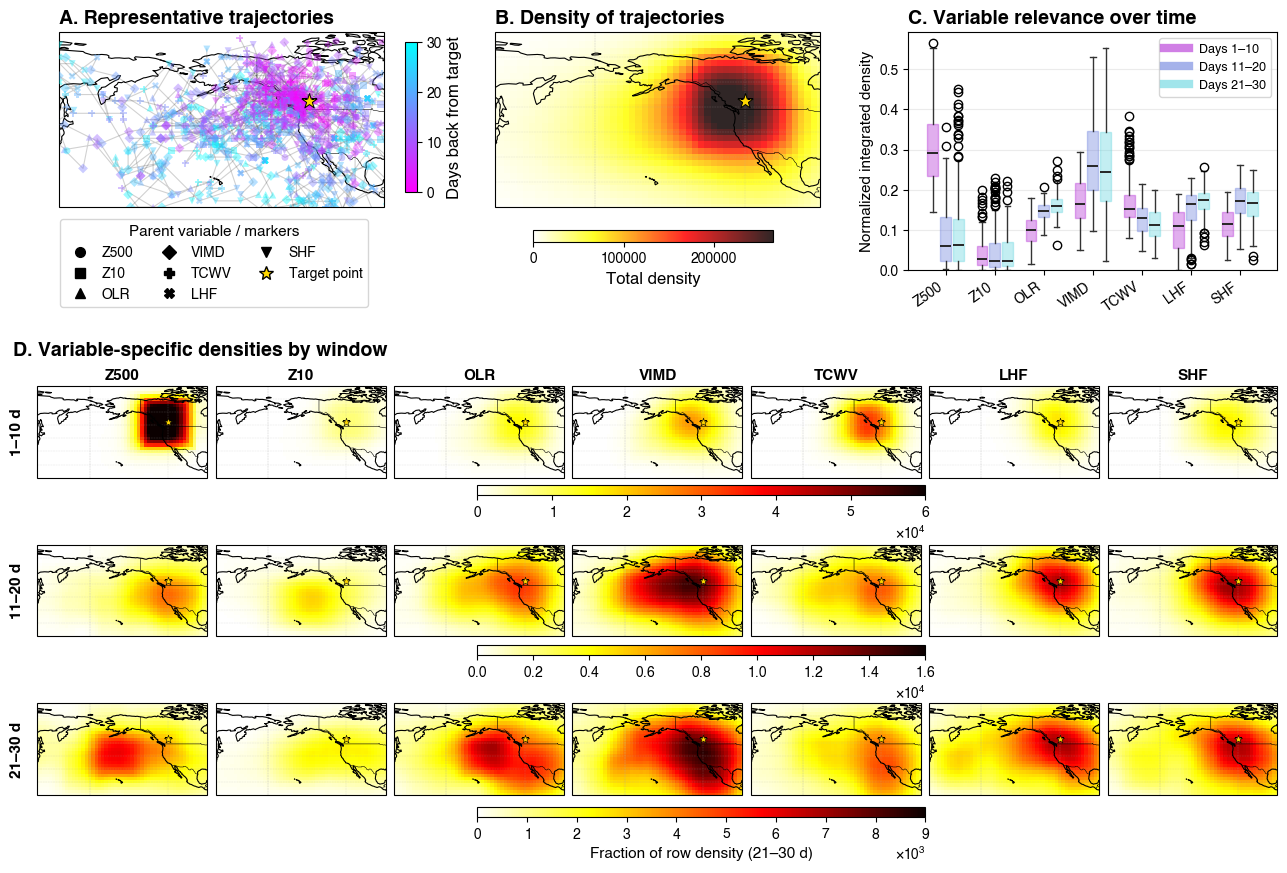

In [99]:

fig_pnw = plot_trace_st_pnw_main_figure(
    pooled_members,
    full_data_run,
    n_rep_traj=50,
    seed=11,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1–10 d", "11–20 d", "21–30 d"),
    extent=(90, -40, 10, 80),
    central_longitude=180,
    event_lon=event_lon,
    event_lat=event_lat,
    p_lo=10,
    p_hi=85,
)

plt.show()

# Optional save
fig_pnw.savefig("fig4_pnw21a_v3.pdf", bbox_inches="tight")

In [100]:
def plot_pnw_physical_patterns_stacked_mean_std(
    full_data_run,
    pooled_members,
    *,
    date_end,
    event_lon,
    event_lat,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    timeres_days=1.0,

    mean_cmap="RdBu_r",
    mean_vmin=-1.5,
    mean_vmax=1.5,

    std_cmap="viridis",
    std_vmin=0.0,
    std_vmax=1.5,

    contour_color="k",
    contour_linewidths=(1.0,),
    contour_percentiles=(97,),
    normalize_density_rows=True,
):
    import xarray as xr
    import pandas as pd
    import numpy as np
    import matplotlib.gridspec as gridspec
    import cartopy.crs as ccrs

    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    # --------------------------------------------------
    # Small helpers
    # --------------------------------------------------
    def composite_field_for_window(var_name, a, b, mode="mean"):
        date_end_ts = pd.Timestamp(date_end)
        fields = []

        for step_idx in range(int(a), int(b)):
            target_time = date_end_ts - pd.Timedelta(days=float(step_idx) * float(timeres_days))
            da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
            fields.append(da)

        da_all = xr.concat(fields, dim="window_step")

        if mode == "mean":
            return da_all.mean("window_step")
        elif mode == "std":
            return da_all.std("window_step")
        elif mode == "rms":
            return np.sqrt((da_all ** 2).mean("window_step"))
        else:
            raise ValueError("mode must be 'mean', 'std', or 'rms'")

    def compute_window_density_dict(windows):
        density_dict = {}
        for (a, b) in windows:
            counts, var_names, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
                pooled_members,
                full_data_run=full_data_run,
                t_start=a,
                t_end=b,
            )
            if normalize_density_rows:
                total = counts.sum()
                if total > 0:
                    counts = counts / total

            density_dict[(a, b)] = {
                "counts": counts,
                "var_names": var_names,
                "lats": lats,
                "lons": lons,
            }
        return density_dict

    def draw_block(fig, gs_block, field_mode, cmap, vmin, vmax, start_letter_idx):
        row1 = [("Z500", (0, 10)), ("TCWV", (0, 10))]
        row2 = [("Z500", (10, 20)), ("MVIMD", (10, 20)), ("MTNLWRF", (10, 20)), ("MSSHF", (10, 20))]
        row3 = [("Z500", (20, 30)), ("MVIMD", (20, 30)), ("MTNLWRF", (20, 30)), ("MSLHF", (20, 30))]
        panel_rows = [row1, row2, row3]

        proj = ccrs.PlateCarree(central_longitude=central_longitude)
        axes = []
        mappable_for_cbar = None
        letter_idx = start_letter_idx

        for irow, row_spec in enumerate(panel_rows):
            for icol in range(4):
                if irow == 0 and icol >= 2:
                    continue

                var_name, (a, b) = row_spec[icol]
                ax = fig.add_subplot(gs_block[irow, icol], projection=proj)
                axes.append(ax)

                _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

                da_comp = composite_field_for_window(var_name, a, b, mode=field_mode)

                lons = np.asarray(da_comp[lon_name].values, dtype=float)
                lats = np.asarray(da_comp[lat_name].values, dtype=float)
                vals = np.asarray(da_comp.values, dtype=float)

                lon_pm = ((lons + 180) % 360) - 180
                order = np.argsort(lon_pm)

                mesh = ax.pcolormesh(
                    lon_pm[order],
                    lats,
                    vals[:, order],
                    transform=ccrs.PlateCarree(),
                    shading="auto",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    zorder=1,
                    rasterized=True
                )
                mappable_for_cbar = mesh

                # Density contours
                dens_info = density_dict[(a, b)]
                counts = dens_info["counts"]
                var_names = dens_info["var_names"]

                k = var_names.index(var_name)
                dens2d = counts[k]

                lons_d = np.asarray(dens_info["lons"], dtype=float)
                lats_d = np.asarray(dens_info["lats"], dtype=float)

                lon_pm_d = ((lons_d + 180) % 360) - 180
                order_d = np.argsort(lon_pm_d)
                dens_plot = dens2d[:, order_d]

                pos = dens_plot[np.isfinite(dens_plot)]
                pos = pos[pos > 0]

                if pos.size > 0:
                    levels = np.percentile(pos, contour_percentiles)
                    levels = np.unique(levels)
                    if len(levels) > 0:
                        ax.contour(
                            lon_pm_d[order_d],
                            lats_d,
                            dens_plot,
                            levels=levels,
                            colors=[contour_color] * len(levels),
                            linewidths=contour_linewidths[:len(levels)],
                            transform=ccrs.PlateCarree(),
                            zorder=3,
                        )

                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker="*",
                    s=55,
                    color="gold",
                    edgecolor="k",
                    linewidth=0.5,
                    transform=ccrs.PlateCarree(),
                    zorder=4,
                )

                label = VAR_LABELS_PNW.get(var_name, var_name)
                win_label = (
                    "1–10 d" if (a, b) == (0, 10)
                    else "11–20 d" if (a, b) == (10, 20)
                    else "21–30 d"
                )

                ax.set_title(
                    f"{chr(65 + letter_idx)}. {label} ({win_label})",
                    loc="left",
                    fontsize=11,
                    fontweight="bold",
                    pad=4,
                )
                letter_idx += 1

        # top-right colorbar slot for this block
        tmp_ax = fig.add_subplot(gs_block[0, 2:4])
        pos = tmp_ax.get_position()
        tmp_ax.remove()

        cax = fig.add_axes([
            pos.x0 + 0.20 * pos.width,
            pos.y0 + 0.58 * pos.height,
            0.60 * pos.width,
            0.10 * pos.height
        ])

        cb = fig.colorbar(mappable_for_cbar, cax=cax, orientation="horizontal")
        cb_label = "Mean standardized anomaly" if field_mode == "mean" else "Standard deviation"
        cb.set_label(cb_label, fontsize=11)
        cb.ax.tick_params(labelsize=9)
        cb.outline.set_linewidth(0.8)

        return axes, letter_idx

    # --------------------------------------------------
    # Shared density dict
    # --------------------------------------------------
    all_windows = [(0, 10), (10, 20), (20, 30)]
    density_dict = compute_window_density_dict(all_windows)

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------
    fig = plt.figure(figsize=(15, 12))
    outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.08)

    gs_top = gridspec.GridSpecFromSubplotSpec(
        3, 4, subplot_spec=outer[0], hspace=0.25, wspace=0.08
    )
    gs_bot = gridspec.GridSpecFromSubplotSpec(
        3, 4, subplot_spec=outer[1], hspace=0.25, wspace=0.08
    )

    axes_top, next_letter = draw_block(
        fig, gs_top,
        field_mode="mean",
        cmap=mean_cmap,
        vmin=mean_vmin,
        vmax=mean_vmax,
        start_letter_idx=0,
    )

    axes_bot, _ = draw_block(
        fig, gs_bot,
        field_mode="std",
        cmap=std_cmap,
        vmin=std_vmin,
        vmax=std_vmax,
        start_letter_idx=10,
    )

    # Optional section labels
    pos_top = fig.add_subplot(outer[0]).get_position()
    plt.gca().remove()
    pos_bot = fig.add_subplot(outer[1]).get_position()
    plt.gca().remove()

    # fig.text(pos_top.x0, pos_top.y1 + 0.01, "Mean anomalies", fontsize=14, fontweight="bold", ha="left", va="bottom")
    # fig.text(pos_bot.x0, pos_bot.y1 + 0.01, "Standard deviation", fontsize=14, fontweight="bold", ha="left", va="bottom")

    return fig, axes_top + axes_bot

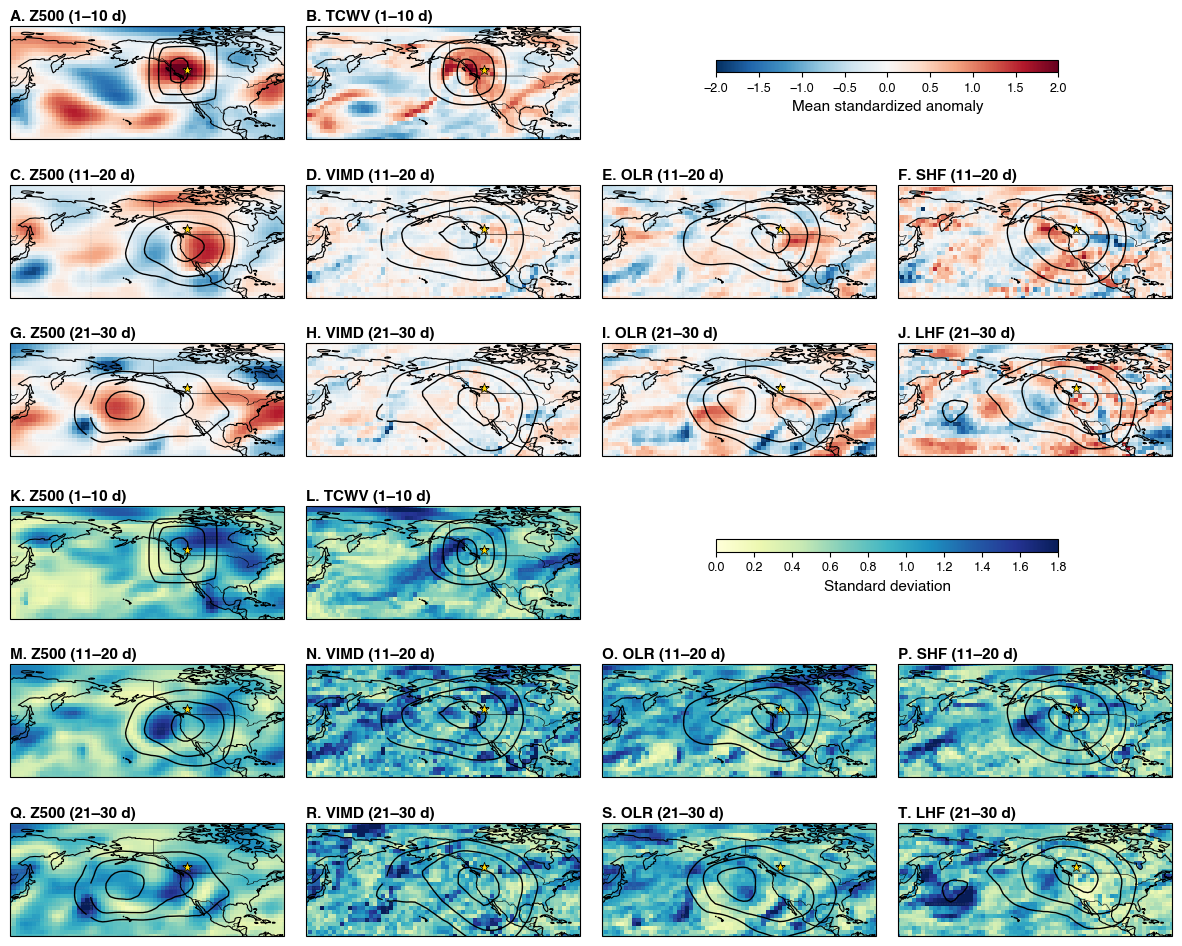

In [111]:
fig5_stack, axes5_stack = plot_pnw_physical_patterns_stacked_mean_std(
    full_data_run=full_data_run,
    pooled_members=pooled_members,
    date_end=date_end,
    event_lon=event_lon,
    event_lat=event_lat,
    extent=(120, -50, 10, 80),
    central_longitude=180,

    mean_cmap="RdBu_r",
    mean_vmin=-2,
    mean_vmax=2,

    std_cmap="YlGnBu",
    std_vmin=0.0,
    std_vmax=1.8,

    contour_color="k",
    contour_linewidths=[1,1,1],
    contour_percentiles=[90,95,99],
    normalize_density_rows=True,
)

plt.show()

fig5_stack.savefig('fig5_pnw21b_v3.pdf',bbox_inches='tight')

In [152]:
def plot_pnw_physical_patterns_figure_mean_plus_stdcontours(
    full_data_run,
    pooled_members,
    *,
    date_end,
    event_lon,
    event_lat,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    timeres_days=1.0,
    anomaly_cmap="RdBu_r",
    anomaly_vmin=-1.5,
    anomaly_vmax=1.5,
    std_contour_color="k",
    std_contour_linewidths=(0.8, 1.2, 1.8),
    std_contour_levels=(1.5, 2.0, 3.0),
):
    import xarray as xr
    import pandas as pd
    import numpy as np

    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    # --------------------------------------------------
    # Small helpers
    # --------------------------------------------------
    def composite_field_for_window(var_name, a, b, mode="mean"):
        date_end_ts = pd.Timestamp(date_end)
        fields = []

        for step_idx in range(int(a), int(b)):
            target_time = date_end_ts - pd.Timedelta(days=float(step_idx) * float(timeres_days))
            da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
            fields.append(da)

        da_all = xr.concat(fields, dim="window_step")

        if mode == "mean":
            return da_all.mean("window_step")
        elif mode == "std":
            return da_all.std("window_step")
        elif mode == "rms":
            return np.sqrt((da_all ** 2).mean("window_step"))
        else:
            raise ValueError("mode must be 'mean', 'std', or 'rms'")

    # --------------------------------------------------
    # Panel layout
    # --------------------------------------------------
    row1 = [("Z500", (0, 10)), ("TCWV", (0, 10))]
    row2 = [("Z500", (10, 20)), ("MVIMD", (10, 20)), ("MSLHF", (10, 20)), ("MSSHF", (10, 20))]
    row3 = [("Z500", (20, 30)), ("MTNLWRF", (20, 30)), ("MSLHF", (20, 30)), ("MSSHF", (20, 30))]

    panel_rows = [row1, row2, row3]
    panel_letters = list("ABCDEFGHIJ")

    proj = ccrs.PlateCarree(central_longitude=central_longitude)

    fig = plt.figure(figsize=(15, 6))
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.08)

    axes = []
    mappable_for_cbar = None
    letter_idx = 0

    # --------------------------------------------------
    # Plot panels
    # --------------------------------------------------
    for irow, row_spec in enumerate(panel_rows):
        for icol in range(4):

            # row 1 uses only first 2 slots
            if irow == 0 and icol >= 2:
                continue

            var_name, (a, b) = row_spec[icol]
            ax = fig.add_subplot(gs[irow, icol], projection=proj)
            axes.append(ax)

            _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

            # ------------------------------------------
            # Mean anomaly in the background
            # ------------------------------------------
            da_mean = composite_field_for_window(var_name, a, b, mode="mean")

            lons = np.asarray(da_mean[lon_name].values, dtype=float)
            lats = np.asarray(da_mean[lat_name].values, dtype=float)
            vals_mean = np.asarray(da_mean.values, dtype=float)

            lon_pm = ((lons + 180) % 360) - 180
            order = np.argsort(lon_pm)

            mesh = ax.pcolormesh(
                lon_pm[order],
                lats,
                vals_mean[:, order],
                transform=ccrs.PlateCarree(),
                shading="auto",
                cmap=anomaly_cmap,
                vmin=anomaly_vmin,
                vmax=anomaly_vmax,
                zorder=1,
            )
            mappable_for_cbar = mesh

            # ------------------------------------------
            # STD contours on top
            # ------------------------------------------
            da_std = composite_field_for_window(var_name, a, b, mode="std")
            vals_std = np.asarray(da_std.values, dtype=float)
            vals_std_plot = vals_std[:, order]

            valid_levels = [lev for lev in std_contour_levels if np.nanmax(vals_std_plot) >= lev]

            if len(valid_levels) > 0:
                lw = list(std_contour_linewidths[:len(valid_levels)])
                if len(lw) < len(valid_levels):
                    lw = lw + [std_contour_linewidths[-1]] * (len(valid_levels) - len(lw))

                ax.contour(
                    lon_pm[order],
                    lats,
                    vals_std_plot,
                    levels=valid_levels,
                    colors=[std_contour_color] * len(valid_levels),
                    linewidths=lw,
                    transform=ccrs.PlateCarree(),
                    zorder=3,
                )

            # ------------------------------------------
            # Target point
            # ------------------------------------------
            ax.scatter(
                ((event_lon + 180) % 360) - 180,
                event_lat,
                marker="*",
                s=55,
                color="gold",
                edgecolor="k",
                linewidth=0.5,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )

            label = VAR_LABELS_PNW.get(var_name, var_name)
            win_label = (
                "1–10 d" if (a, b) == (0, 10)
                else "11–20 d" if (a, b) == (10, 20)
                else "21–30 d"
            )

            ax.set_title(
                f"{panel_letters[letter_idx]}. {label} ({win_label})",
                loc="left",
                fontsize=12,
                fontweight="bold",
                pad=5,
            )
            letter_idx += 1

    # --------------------------------------------------
    # Smaller colorbar in the top-right blank area
    # --------------------------------------------------
    tmp_ax = fig.add_subplot(gs[0, 2:4])
    pos = tmp_ax.get_position()
    tmp_ax.remove()

    cax = fig.add_axes([
        pos.x0 + 0.05 * pos.width,
        pos.y0 + 0.58 * pos.height,
        0.60 * pos.width,
        0.10 * pos.height
    ])

    cb = fig.colorbar(mappable_for_cbar, cax=cax, orientation="horizontal")
    cb.set_label("Mean standardized anomaly", fontsize=12)
    cb.ax.tick_params(labelsize=10)
    cb.outline.set_linewidth(0.8)

    return fig, axes

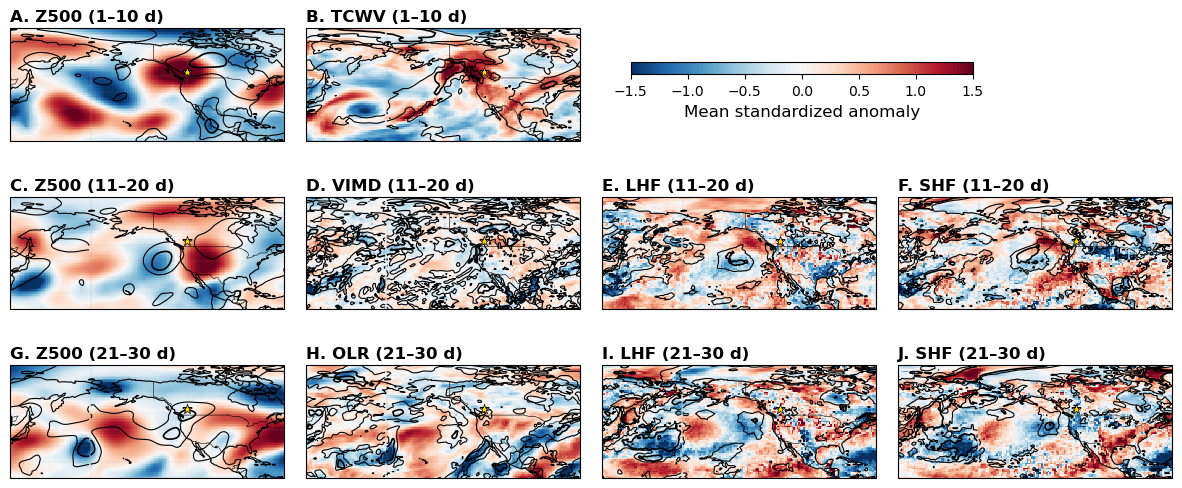

In [154]:
fig5_hybrid, axes5_hybrid = plot_pnw_physical_patterns_figure_mean_plus_stdcontours(
    full_data_run=full_data_run,
    pooled_members=pooled_members,
    date_end=date_end,
    event_lon=event_lon,
    event_lat=event_lat,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    timeres_days=1.0,
    anomaly_cmap="RdBu_r",
    anomaly_vmin=-1.5,
    anomaly_vmax=1.5,
    std_contour_color="k",
    std_contour_linewidths=(0.8, 1.2),
    std_contour_levels=(1., 1.5),
)

plt.show()

In [135]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def composite_field_for_window(
    full_data_run,
    var_name,
    *,
    date_end,
    t_start,
    t_end,
    timeres_days=1.0,
    mode="mean",   # "mean", "std", "rms"
):
    date_end_ts = pd.Timestamp(date_end)

    fields = []
    for step_idx in range(int(t_start), int(t_end)):
        target_time = date_end_ts - pd.Timedelta(days=float(step_idx) * float(timeres_days))
        da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
        fields.append(da)

    da_all = xr.concat(fields, dim="window_step")

    if mode == "mean":
        return da_all.mean("window_step")
    elif mode == "std":
        return da_all.std("window_step")
    elif mode == "rms":
        return np.sqrt((da_all ** 2).mean("window_step"))
    else:
        raise ValueError("mode must be 'mean', 'std', or 'rms'")

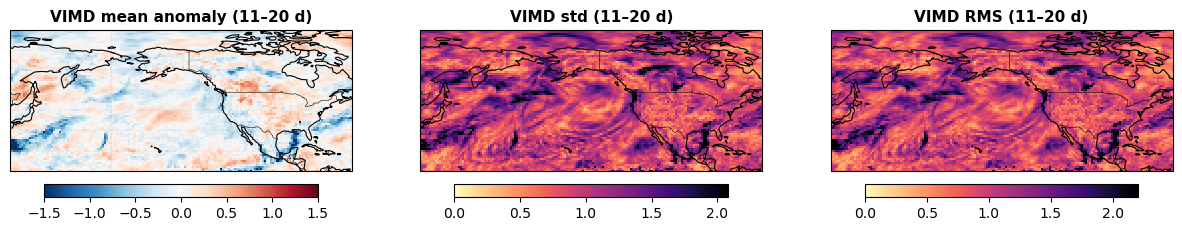

In [136]:
lat_name, lon_name = _infer_lat_lon_names(full_data_run)

m_mean = composite_field_for_window(
    full_data_run, "MVIMD",
    date_end=date_end, t_start=10, t_end=20,
    timeres_days=1.0, mode="mean"
)

m_std = composite_field_for_window(
    full_data_run, "MVIMD",
    date_end=date_end, t_start=10, t_end=20,
    timeres_days=1.0, mode="std"
)

m_rms = composite_field_for_window(
    full_data_run, "MVIMD",
    date_end=date_end, t_start=10, t_end=20,
    timeres_days=1.0, mode="rms"
)

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.2),
    subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180))
)

for ax, da, title, cmap, vmin, vmax in [
    (axes[0], m_mean, "VIMD mean anomaly (11–20 d)", "RdBu_r", -1.5, 1.5),
    (axes[1], m_std,  "VIMD std (11–20 d)",          "magma_r", 0, float(m_std.quantile(0.99))),
    (axes[2], m_rms,  "VIMD RMS (11–20 d)",          "magma_r", 0, float(m_rms.quantile(0.99))),
]:
    _style_geo_ax(ax, extent=(120, -50, 10, 80), central_longitude=180, add_grid=True)

    lons = np.asarray(da[lon_name].values, dtype=float)
    lats = np.asarray(da[lat_name].values, dtype=float)
    vals = np.asarray(da.values, dtype=float)

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)

    mesh = ax.pcolormesh(
        lon_pm[order], lats, vals[:, order],
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap, vmin=vmin, vmax=vmax
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.8)

plt.show()